In [ ]:
!curl -s https://raw.githubusercontent.com/agricolamz/2025_morphological_transducers/refs/heads/main/task_tests/Makefile -o Makefile; make

In [8]:
! curl -s https://apertium.projectjj.com/apt/install-nightly.sh | sudo bash
! sudo apt-get install hfst lexd

In [ ]:
!rm -rf /content/*

#Обработка словарей

промпт: необходимо привести этот файл в csv вида агульское слово, русский перевод, часть речи(в соответствии с русским переводом)

In [9]:
import pandas as pd

In [10]:
dct1 = pd.read_csv('mazanaev_dict.csv').drop(columns='Unnamed: 0')
dct2 = pd.read_csv('khailov_dict.csv')

In [11]:
dictionary = pd.concat([dct1[['агульское слово', 'русский перевод', 'часть речи']], dct2]).drop_duplicates(subset='агульское слово')

In [12]:
dictionary

,агульское слово,русский перевод,часть речи
0,абаб,тётя,существительное
1,абажур,абажур,существительное
2,абанемент,абонемент,существительное
3,абанент,абонент,существительное
4,абанкьул,лоб,существительное
...,...,...,...
1221,сухIур,волшебство/колдовство,существительное
1222,сухIурчи хьир,колдунья/ведьма,существительное
1223,эхьI,призрак,существительное
1224,уларикес кегъархьа зад,призрак,существительное


In [13]:
dictionary['часть речи'].value_counts()

,count
часть речи,
существительное,3628
прилагательное,937
глагол,673
наречие,542
числительное,54
местоимение,47
частица,21
союз,9
междометие,6


In [14]:
#generate lexicon files
import re

def is_compound(word):
    if not isinstance(word, str):
        return True
    return bool(re.search(r'[\s\-]', word.strip()))

dct_filtered = dictionary[~dictionary['агульское слово'].apply(is_compound)].copy()

pos_mapping = {
    'существительное': 'nouns',
    'прилагательное': 'adjectives',
    'глагол': 'verbs',
    'числительное': 'numerals',
    'наречие': 'adverbs',
    'частица': 'particles',
    'местоимение' : 'pronouns'
}

for russian_pos, english_pos in pos_mapping.items():
    subset = dct_filtered[dct_filtered['часть речи'] == russian_pos]

    filename = f"aghul_{english_pos}_lexicon.lexd"
    with open(filename, 'w', encoding='utf-8') as f:
        for _, row in subset.iterrows():
            aghul_word = str(row['агульское слово']).strip().replace('I', 'l')
            russian_trans = str(row['русский перевод']).strip()
            f.write(f"{aghul_word} #{russian_trans}\n")

    print(f"Создан файл {filename} с {len(subset)} записями")

print(dct_filtered['часть речи'].value_counts())


Создан файл aghul_nouns_lexicon.lexd с 3036 записями
Создан файл aghul_adjectives_lexicon.lexd с 680 записями
Создан файл aghul_verbs_lexicon.lexd с 270 записями
Создан файл aghul_numerals_lexicon.lexd с 52 записями
Создан файл aghul_adverbs_lexicon.lexd с 407 записями
Создан файл aghul_particles_lexicon.lexd с 20 записями
Создан файл aghul_pronouns_lexicon.lexd с 44 записями
часть речи
существительное    3036
прилагательное      680
наречие             407
глагол              270
числительное         52
местоимение          44
частица              20
союз                  9
междометие            4
предлог               4
вводное слово         3
союзное слово         2
деепричастие          1
Name: count, dtype: int64


In [15]:
# @title nouns
%%writefile aghul_nouns_lexicon.lexd
LEXICON Noun
абаб #тётя
абажур #абажур
абанемент #абонемент
абанент #абонент
абанкьул #лоб
абдал #дурак; глупец
абдалвел #тупость
абзац #абзац
абитуриент #абитуриент
аблигаци #облигация
аборт #аборт
абояр #обои
абразец #образец
абур #честь
абурар #скромность; приличие
абурлувел #честь
абъект #объект
абъем #объём
аваз #клевета; сплетня
аваз #напев
аваза #известие; слух; молва
авантюра #авантюра
авантюрист #авантюрист
август #август
авчи #охотник
авчивел #охота
агнемёт #огнемёт
агуб #вид; облик
агубар #внешность; наружность; образ
агудж #вес
агъ #бедро; ляжка
агъ #бязь
агъа #господин
агъзур #кила; тонна
агъу #яд
агьилвел #старость
агьрам #рычаг
агlай #улитка
ад #ляжка
ад #преисподняя
адаб #совесть; воспитанность
адабият #литература
адаблувел #стеснительность
адаверевус #спуск
адад #дядя
адсузвел #безвестность
аджутъвел #ярость
аджутъсузвел #беззлобность
аджукъ #зависть
аждагьа #дракон
азадвел #независимость
азар #болезнь; зараза
азархана #больница
азгъунвел #упрямство
азият #боль; мучение
азияткар #мученик
азманвел #рост
айван #балкон; веранда; терраса
айгъур #жеребец
аккуьшуб #заброшенность; обветшалость
алагъшуб #рвота
аларуджуб #скрученность
аларуцавус #поворот
алача #кляча
алачух #палатка; шатёр
алгъадиб #разъярённость
алгъузуф #наблюдатель
алдиджи #обмотка
алифбе #азбука
алкъан #аркан
алархьуб #напасть
алучlуб #упорство
алмас #алмаз; стеклорез
алукас #налёт
алукуб #нападение
алухlуб #перепалка; ссора; ругательство; брань
алухlубар #ругательство
алучlубар #старание
алчагь #негодяй; подлец
алчагьвел #гнусавость
алчихьас #умножение
алчихьуб #обговаривание; заклинание; наговор; клевета
аманат #поручение; завещание
амир #приказ
аннамазвел #упрямство
апкьан #обед
апрел #апрель
ара #промежуток; пауза
аран #полоскость
араттор #оратор
арбягъ #среда
арганизаци #организация
арифметика #арифметика
аришвариш #торговля
аришваришчи #торговец
аркестр #оркестр
армени #армянин
арс #серебро
артил #артель
арх #канава
архайинвел #спокойствие
арчlуб #обветшалость
арчlувел #разрушенность; разорённость
арчlувусар #развалины
асир #век
аслан #лев
асланвел #мужество
аспирант #аспирант
аспирантура #аспирантура
ассистент #ассистент
аставел #осторожность
астт #подол
асттраноми #астрономия
атом #атом
аттархьевел #беспутство
аттверевус #выход
аттракцион #аттракцион
афар #пироги
афекьуф #ассистент
афтобиографи #автобиография
афтомат #автомат
афтопортрет #автопортрет
афторучка #авторучка
афтостанци #автостанция
афттабуз #автобус
ахсарар #заря
ахсари #рассвет
ахта #мерин
ахттигьар #позволение; разрешение; полномочие; право
ахттилат #разговор; беседа; слово; рассказ
ахттилатчи #собеседник
ахlаджихlуб #помощь; забота
ахlакьас #признание
ахыхьуб #погоня
ахlабаб #бабушка
ахlадад #дедушка
ахlаф #голова (должностное лицо)
ацlувел #полнота
ачаверевус #вход
ачухьвел #настроение
аш #каша; плов
ашбаз #повар
ашкlин #вдовец
ашна #знакомый; приятель
ашнавел #знакомство
ашузан #черпак
ашхана #столовая
ашчи #дармоед
аяз #холод; мороз; стужа
баб #мать
багами #утро
багаминттар #завтрак
багв #бок; сторона
багниш #медведь
багунттар #родня
багур #дурак
багъ #сад
багъ #фитиль
багълу #пачка
багъманчи #садовод
багъчи #садовод
багьадур #богатырь
багьана #причина; повод
багьачи #торговец
багьна #повод
багlтlур #грязь
бадан #туловище
бадбад #индейка
бадра #ведро
баджанах #свояк
базар #базар
базу #жердь
байкъуш #развалины
байкъуш #сова
байрам #праздник
бак #цистерна
бакъукъ #халва
бакlлихар #фасоль
бала #ребёнок; дитя
балгъан #слизь; мокрота
балла #несчастье; беда
балугъ #рыба
балут #дуб
палут #дуб
балхун #гной
бальница #больница
банд #обруч
баракат #изобилие
бармак #папаха
барут #порох
басня #басня
басрикъ #буря
баттал #чужая (вещь)
баттинккабур #туфли
батlарвел #красота
бахилвел #восхищение
бахт #доля; рок
бахт #счастье
бахттикъара #несчастливец
бахълухъ #кувалда
бачча #кличка
бачl #лапа
башбурт #паспорт
башгъавел #отличие; различие
башчи #главарь
баябан #пустыня
бег #бек
бегьуш #наркоз
бегlли #вишня; черешня
бедгlе #сплетня
без #бязь
белге #улика
бембег #хлопок; вата
беневша #фиалка
бензи #лицо (бессовестное)
бере #время
берхел #палас
берхlем #платье; рубашка
бетl #долька
бетlур #грязь; слякоть
бетlурар #помои
бехlс #зависть
бигь #задаток
бигьар #приход; урожай
бигьи #паяльник
бизарвел #усталость
бизарвелар #неудобство
бика #госпожа
бина #исход/основание
бицlиф #малый (малец)
бишекlв #ястреб
блокнот #блокнот
бокс #бокс
бомба #бомба
борт #борт
борщ #борщ
ботаника #ботаника
бригада #бригада
бронза #бронза
брошюра #брошюра
буг #окраина; сторона
бугъ #пар
бугъа #бык; вол
бугътан #клевета; навет
бугъу #сова
будай #кукла
буй #рост
буйирмишар #замечание
буйругъ #приказ
булбул #соловей
буллах #родник
булур #лупа
бурдж #долг; обязанность
буржум #пружина
буркьун #даргинец
бурма #винт; шуруп
бурмабур #кудри
бурмиш #приказание; поручение
бурт #борт
бурунз #рис
бусракъ #буря
бустан #огород
буфайка #фуфайка
бухьатl #толстяк (толстушка)
бучкка #бочка
бушвел #хрупкость; слабость; худоба
бушкъаб #блюдце
буlуф #тихоня; молчун
буюр #просьба
буярмиш #поручение; приказание
ваба #холера
ваз #месяц; луна
вазир #представитель; посланник
вазифа #обязанность
вазифабур #обязательство
вайсара #причитание
вайшавар #плач; рыдание
вакил #защитник; посол; посланник
вакк #кабан
вакъ #чашка; миска
вакъиа #событие; факт
вакъфа #безвестность
вала #ребёнок; дитя; мальчик
варв #пчела
вардишакъуб #воспитанность
вархавел #расстояние
васият #завещание
ватан #родина; отечество
ватанагьли #соотечественник
ватандаш #гражданин
ватандинф #соотечественник; гражданин
ватанперас #патриот
ватанчи #гражданин
вафа #отдача
вахт #время
вахтт #час; пора
вегьши #дикарь
вегlда #время; срок
вегlз #наставление; проповедь
велвела #шум; крик; переполох
велед #ребёнок; дитя; мальчик
верхь #тополь
вехlши #дикарь
вец #бык; вол
викlегьвел #смелость
вилаят #округа; область
виргул #запятая
врач #врач
гажин #графин
газит #газета
гам #замок
гами #корабль; судно
гамиш #буйвол
гандридж #иней
гап #ладонь
гаргар #колокольчик
гардан #шея
гарданбаз #хомут
гарухар #фасоль
гарч #половина
гаф #слово; разговор
гаш #голод
гашвел #голод/скупость
гашинф #жадный (человек)
гвадж #затылок
гвегlванар #носок; чулок
геда #мальчик; юноша; парень; сын
генев #конопля
гигlван #носок; чулок
гим #годекан
гиранвел #обида
гирванкка #фунт
гирекхъуб #надобность; необходимость
гитан #кошка
гуг #череп
гугурт #сера
гудж #сила; мощь
гуджлувел #сила; могущество
гула #пуля
гулуб1 #исчезновение
гулуб #потеря
гулуф #безвестность
гунагь #грех
гунагьчи #грешник; нечестивец
гуни #хлеб
гунтl #копна
гурджи #грузин
гучl #испуг; страх
гучlвел #испуг; страх; боязнь
гучlевел #трусость
гучlрахl #трус
гучlрахlвел #трусость
гьудег #буйволёнок
гьузги #зеркало
гьузел #красавица
гьузелвел #красота
гьузчи #наблюдатель; шпион
гьулге #зонт
гьулерш #клей
гьулеш #клей
гьулишанвел #красота
гюлейтlар #гулянье
гюна #юг
гьаб #чашка
гьавур #понимание; осознание
гьад #молот; молоток
гьадахъай #булавка
гьаз #зелень
гьазевел #свежесть
гьалатl #ошибка
гьалибвел #победа
гьам #печаль; скорбь; тоска; переживание; горе
гьамсузвел #беспечность; беззаботность
гьараг #ожерелье
гьарачи #грабитель; разбойник
гьарибвел #худоба; худощавость
гьархьалай #соня
гьвад #потолок; крыша
гьван #камень
гьванкlар #север
гыба #клевета; сплетня
гьибгьер #рябина
гьивгьар #брусника
гьил #рука
гьилив #рукав
гьират #честь
гьиратлувел #ревность
гьирд #липа
гьирхlуб #запинка; задержка
гьузуб #запинка; задержка; перерыв
гьуй #собака; пёс; овчарка
гьулантт #покупатель
гьурагъал #яйцо
гьурбат #чужбина
гьургьуб #спор; перепалка
гьурд #кулак
гьурт #пена
гьух #горло
гьава #воздух; атмосфера; среда; климат; погода/мотив/чувство
гьававел #высота
гьараяр #шум; переполох
гьевес #чувство
гьеджат #нужда
гьез #наслаждение
гьекl #цена
гьел #стрела
гьерттар #разное
гьетебете #лепет
гьеч #яблоко
гьиндуьшкка #индюшка
гьинкl #икота
гьудуркlуб #недостаток; изъян
гьунар #заслуга/подвиг
гьунарчи #фокусник
гьундур #повеса
гьучархьуб #встреча
гьучихьас #рекомендация; предложение
гьуькум #наказание
гlагьуюб #неправда
гlад #звезда
гlадулвел #мягкость
гlазаб #мучение
гlайиб #стыд
гlан #нутро/двор
гlайнабур #очки
гlабахь #вечер
гlабдал #болван
гlабиччай #болван
гlар #пастбище; сенокос
гlарза #жалоба
гlаруцай #шалопай/попрошайка
гlархьуб #развращенность
гlаттивуй #выбор
гlатlуб #общительность
гlатlушвел #общительность
гlафна #огурец
гlахъуб #беспорядок
гlачучlуб #участие
гlашкъ #увлечение; страсть
гlебиччи #болван
гlедат #обычай; адат; традиция
гlеджибанвел #странность; необычность
гlеджиз #бедняк
гlеджизвел #бедность; нищета; нужда
гlезаб #мука; мучение; боль
гlезабар #страдания
гlемчи #чихание; чих
гlерекьи #водка
гlерза #заявление
гlерзачи #заявитель
гlерсузвел #бессовестность
гlетlлас #атлас
гlешкъ #желание
гlешкъвел #увлечённость
гlешукъ #ашуг
гlибар #бусы
гlилимлувел #научность
гlилми #наука
гlинчl #улыбка
гlифрит #демон; дьявол
гlифритвел #хитрость
гlуб #лягушка
гlуд #куропатка
гlудафанар #близнецы
гlудулвел #мягкость
гlуй #картошка
гlул #лето
гlун #плечо
гlунар #спина
гlур #заяц; кролик/мука; тесто
гlургlур #слизь; мокрота
гlурч #охота
гlурчахьан #охотник
гlурчевел #охота
гlуьбехь #вечер
гlэшкъвел #устремлённость
дабакь #ящур
дабакьвел #хромота
дабан #каблук
давамлувел #долгота
давдагъ #дурень; оболтус
давур #период; век
даги #ишак; осёл
дагучlуб #смелость
дагъал #осколок
дагъутстандинф #дагестанец
дагъутстанлу #дагестанец
дагьар #гора; скала
дагьур #серп
дагlайвел #неосведомлённость
дагlви #война
дад #отец; папа/вкус
дазу #граница
дайиб #отказ
дакьикьа #минута
дакlар #окно
далай #песня; частушка
далгъуб #разрушение; хаос
далдам #барабан
далдамчи #барабанщик
далил #аргумент; довод
даллу #дурак; дурень
даллувел #дурость
дамакъар #высокомерие
дамакъвел #заносчивость; зазнайство
дамар #сустав
дамашникар #чувяки
дамдам #барабан
дамдамчи #барабанщик
даммар #жила
данг #стук; лязг; звон
дар1 #палка; балка; брус
дар #лес
дар3 #стебелёк
дараджа #положение
дарамат #сооружение; здание
даран #кабан
дарвел #узость; теснота
дард #переживание; скорбь; горе; тоска; мучение
даринвел #глубина
дарискьалвел #мелочность
дарихвел #тоска; скука
дарман #лекарство
дарманар #медикаменты
дарс #урок
дарчин #корица
дасмал #полотенце
даста #пачка
дастта #пучок
дафтт #бубен
дафттар #книга
дахил #полочка
дач #пачка
дашбаш #подношение; взятка
даягъ #опора
даягъвел #заступничество
дева #верблюд
девекъуш #страус
девлет #богатство; состояние
девлетар #состоятельность; богатство; ресурсы
девлетвел #состоятельность; зажиточность
девлетлу #богач
дегьна #водоворот
дегlви #война; фронт
декабр #декабрь
делек #парикмахер
делекхана #парикмахерская
демек #курятник
дере #долина; ущелье
дерей #шёлк
дерейинф #земляк
дерец #соха
диб #основа
дибахарай #тафта
диван #суд
дилаварвел #красноречивость
дилмаш #полиглот
дин #религия; вера
дирбаш #умелец/храбрец
дирбашвел #мужество
диф #туман
дишагьли #женщина
дудай #кукла
дудук #свисток
дуджурай #свёрток
дузалвел #справедливость
дузан #равнина
дузвел #правдивость; честность; прямота; справедливость; непорочность; верность
дуздавевел #несправедливость
дукан #магазин
дукьуб #шов
дукьум #нить
дукl #просо
дул #приплод
дулег #селезёнка
дуллугъ #заработок
дулма #голубцы
дунгъуз #ругательство
дунгъузугъли #ругательство
дурахал #ножовка; пила
дурахlелар #игра
дурби #бинокль
дурна #журавль
дуруц #соха
дурхlуб #фокус
дурхlубар #игра
дустт #друг; приятель
дусттагъ #тюрьма
духттур #доктор; медик; врач; фельдшер
дуч #вязанка
душман #враг
душманвел #вражда
дуя #мир; вселенная
дуьгlе #молитва
дуьлбен #тюрбан
дуьрбебур #бинокль
дуьхьуьб #согласие; примирение/удача
джаваб #ответ
джагв #белизна
джад #кузница
джаза #наказание; взыскание; штраф
джазасузвел #безнаказанность
джакьв #птица; воробей
джал #забор; плетень
джалгъа #ряд/тропинка
джаллатl #палач
джам #итог; сумма
джан #туловище
джандак #тело
джанджалвел #алчность
джаннат #рай
джар #сметана/слой
джарга #строй
джарх #овёс
джасад #тело; труп
джасус #шпион
джафа #старание; усилие; труд
джафасузвел #простота; доступность
джетельем #ад; преисподняя
джекьетl #рябчик
джемеlет #общество
дженг #борьба
дженнет #рай
джерехl #целитель; хирург
джилд #переплёт
джимилар #кизил
джин #джин
джинакьуб #тайна
джиневел #тайна
джинегв #ястреб
джихер #груша
джиял #участок
джуваб #ответ
джугьутl #еврей
джудж #тетрадь
джумартвел #щедрость
джуматвел #щедрость
джуна #марля; бинт
джуревел #отличие; разница; разное; разновидность
джуревелар #перемена
джут #пара
джуьмlа #пятница
единица #единица
езид #изменник; предатель
езидвел #измена; предательство
елкан #парус
емаг #еда; пища
емиш #плод; фрукт
ерсеф #обветшалость; ветхость
ерсузвел #легкомысленность
ерхевел #рост
ерlевел #ширина
есир #плен; пленник
етим #сирота
етум #сирота
жугъри #персик
жулуркъ #жулик
жуьлез #селезёнка
забунвел #худоба; хрупкость
забунвелар #худощавость
забур #пластырь
зав #нёбо
завал #несчастье; бедствие
завар #нёбо/грохот
загьмат #труд; усилие
зад #вещь
заз #колючка; шип; заноза
закат #налог
залзала #землетрясение
залумат #гнёт; угнетение
замана #время
замин #залог
заминвел #поручительство
занг #звонок
зар #блеск; сияние; позолота
зарар #вред; ущерб
зарарвел #вредность
зарарлувел #вредность
зарарчи #вредитель
зарафат #шутка
зарафатар #юмор; анекдот
зарафатвел #шутовство
зарафатчи #весельчак; шутник
зарафатчивел #шутовство
зарбвел #быстрота
заИнфвел #худоба
зегьер #яд
зегьмат #старание; усилие; труд
зейтун #маслина; оливка
зерфел #сито
зибз #муравей
зибз #рябина
зигьин #восприимчивость
зикри #радение
зиндан #яма
зиянкар #вредитель
зиянкарвел #вредность
зугьмат #запах; вонь
зулмат #жестокость
зулмат #беспросветность
зулум #насилие; тирания
зулумар #жестокость; угнетение; гнёт
зулумкар #угнетатель; тиран
зур #моча
зурба #храбрец
зурбавел #ловкость; умение
зурбавел #сила; смелость
зурд #ясень
зурна #зурна
зуьлер #крыльцо
зуьлерз #селезёнка
ибагlвел #тепло
ибгlай #тепло
иблис #чёрт; демон; дьявол
ибрахъан #серьга
ибур #ухо
ибурихъан #серьга
ибхь #снег
ивра #жеребенок
ивриккен #серьга
ивур #ухо
игит #храбрец; герой
игитвел #мужество; героизм
игитди #мужество
идара #учреждение; организация; контора; управление
идеми #человек; мужчина
идемивел #человечность
идемивел #мужество
иджвел #добро; доброта; благо; благость
иджвеел #мягкость
изан #пахота; пашня
изин #благословение
икрагь #отвращение
иккевел #худоба
иккевелар #худощавость
икърар #договорённость; обговаривание; соглашение; подтверждение; признание
илан #змея
илдеш #друг; товарищ
илдешвел #товарищество
иллевел #мужество
иллеф #мужество
имам #имам
иман #вера
иманвел #покорность
инджир #инжир
инн #боярышник
инсан #человек
инсанвел #человечность
инсанф #сострадание; милосердие; пощада
инчl #улыбка
ипак #шёлк
ипцlел #стружка
иревел #краснота
иркк #кость
ирс #наследство
ирхевел #долгота
ирхевел #рост
ирlевел #ширина; широта
ис #возраст; год
исалвел #узость; теснота
испахьи #господин
иститут #перец
исттикан #стакан
исукъ #годовщина
итни #понедельник
иттал #болезнь; заболевание
итlул #петля
иф #медь
ифал #масло
ифрит #дьявол
ифул #лихорадка
ихал #наждак
ихтилат #беседа; разговор
ицlул #запястье
ишан #отметина; метка; след; эмблема; шрам; рубец
ишиг #ящик
ишкатвел #информация
ишкатчи #сплетник
ишкаф #шкаф
ишкил #картина; открытка; фотография
ишкит #донесение
иштагь #аппетит
иштараквел #участие
ишттагь #желание
иъ #кровь
июл #июль
июн #июнь
йиркlв #сердце
йирт #имение
йируш #походка
йирхlубар #побои
кавха #староста
кагъаз #письмо
калам #капуста
калима #слово
калкам #клюв; подбородок
калтуф #картошка
камшир #бронза
кантl #нож
кар #работа; труд; дело
караван #караван
каравел #глухота
касиб #бедняк
касибвел #бедность; нищета; нужда
кафан #саван
кафар #север
кваниш #браслет
квац #гроздь
кедаркуб #наклон
кедаркувус #склон
кела #голова; череп
келагъан #платок
келпит #спичка
келиши #кирпич
келпуш #кирпич
келхъуб #насмешка; издёвка; усмешка
кепек #копейка
кепкил #шумовка
керавел #глухота
керкв #ноготь
кеспи #ремесло
кеф #наслаждение; удовольствие
кефи #настроение; самочувствие
ки #частица
кикlас #упрек
килавар #вес
килиса #церковь
кимкима #хаос
кирадж #известь; мел
кирачи #арендатор
кирк #ноготь
китаб #книга
киф #наслаждение; удовольствие
киш #суббота
ку #кизяк
куквел #полнота; ожирение
куку #яичница
кул #штанина
кул #ветка; гроздь
кулагь #бусинка; жемчужина
кулак #ветер; метель
кулегъ #бусинка; кадык
кум #пар
кум #дым
кум3 #пыль
кума #землянка
кумак #помощь; поддержка; подмога
кумакчи #помощник
кумевел #тупость; дурость
кумеф #дурак; глупец
кумул #палец
кунар #одежда
купп #кизяк
курвел #слепота
курмаг #дымоход
курси #стул
куруш #веник
курцlул #щенок
куршам #айва
кут #побои
кутал #плуг
кутар #побои
кутегь #конец
кутlул #прут
куц #вид; облик
куч #коса
куча #улица
кучевел #жара
куьгьнавел #староста
куьче #улица
ккабалай #ящерица
ккабан #скотовод; пастух
ккабачккалар #брусника
ккабилай #ящерица
кканчч #выступ; клык
ккачелибур #аттракцион
кквееревус #спуск
ккедихьуб #уничтожение; разрушение
ккейшуб #обветшалость; ветхость
ккейшувусар #развалины; руины
ккекк #петух
ккеку #кукушка
ккел #ягнёнок
ккеттивун #наслаждение
ккикку #кукушка
ккифккир #шумовка
ккубул #ревматизм
ккул #полушубок; шуба; тулуп
ккулинвел #скука; тоска; лень
ккунчl #букет
кукрт #рубашка
къаб #тарелка; чашка
къабан #кабан; вепрь
къабар #посуда
къабахь #тыква
къавахlан #замечание; порицание; упрёк
къавахlан #прозвище
къавум #дыня
къавум #сват
къадагъа #запрет
къадакъ #гвоздь
къаз #гусь
къазалмишар #богатство
къазамат #тюрьма
къазамиш #заработок
къазан #котел
къазанджи #барыш
къайфат #конфета
къакъ #тяжесть; ноша; груз; поклажа
къала #крепость; замок
къалай #олово
къалайчи #лудильщик
къалат #ошибка
къалат #склока
къалат3 #умысел
къалпуз #арбуз
къамат #фигура
къами #обжора
къамиш #тростник
къамчи #плеть
къантlузай #конопля
къапубур #ворота
къараваш #слуга
къаравул #сторож; страж; охрана; караул
къари #старуха
къари #полметра
къариблух #чужбина
къарк #кора
къармах #крюк
къарфун #желудок; живот; обжора; чревоугодник
къархьил #локоть
къатир #мул
къафаз #клетка
къафкъазлу #кавказец
къафлан #тигр
къачагъ #разбойник; грабитель
къвадекь #кожа
къвакъва #чернослив
къвал #бок
къвац #копыто
къев #бутон
къегl #раздор
къейфат #конфета
къемчи #кнут
къерекъел #сорока
къидж #папоротник
къиз #девочка; девушка; дочь
къизгъинвел #разъярённость
къизил #золото
къизилгюль #роза
къизмиш #усталость
къизмиш #жажда
къизмишвел #злоба
къикъевел #тяжесть
къилит #засов
къир #кружево
къирагъ #край; сторона; окраина; берег; перила
къиргъиш #проклятие
къирибур #облака; тучи
къирмизи #платок
къирхаягъ #рак
къубу #купол
къугъ #перо; пух
къуджа #старик
къуй #яма; колодец
къул #подпись; роспись
къулайвел #удобство
къулайсузвел #неудобство
къуллугъ #служба; должность
къуллугъвел #служение
къуллугъчи #чин
къуллугъчи #служащий
къум #песок
къун #горбун
къунши #сосед
къуншивел #соседство
къупп #клюв
къураба #чужак
къурахвел #засуха
къургъушум #свинец
къурумсагъвел #подлость
къурху #испуг; страх; угроза
къурч #пустырь
къускъун #горб
къут #приятель
къучагъ #удалец; храбрец
къучи #разбойник
къучма #друг; подруга; приятель
къуша #пара
къушум #армия; войско
кьаб #опора
кьабул #приятие
кьав #опора
кьавалар #музыканты
кьавкl #моль
кьавул #согласие; приятие
кьада #беда
кьадам #визит; шаг
кьадар #предопределённость; решение
кьадар #стоимость; достоинство
кьадар3 #объём
кьадрисузвел #неблагодарность
кьаза #несчастье
кьайда #мера; степень; величина
кьайде #экономия
кьакь #обхват
кьал #стебелёк
кьалам #карандаш; перо; ручка
кьалар #полынь
кьамкьаш #хрящ
кьаниlэт #экономия
кьаниlэтлувал #экономность
кьапар #нечистоты
кьапач #неряха
кьапlкl #моль
кьарар #постановление
кьарар #терпение
кьарарсузвел #нетерпеливость
кьаратиген #растение
кьаркьала #телосложение
кьартlанай #лопух
кьас #полка
кьаса #смычок
кьасабхана #скотобойня
кьастт #старание; упорство; терпение; воля; цель
кьвадекь #кожа
кьвадилкьван #ковёр; сумах
кьвакь #колено
кьвали #куст
кьвани #короб
кьавlачl #локоть
кьебзур #рассол
кьедибан #ёж
кьел #соль
кьерзул #рассол
къеклел #герой
къеклелвел #героизм
къеклетвел #дефицит
кьец #козёл
кьецлар #щипцы
кьецар #плоскогубцы
кьецlулвел #нагота
кьибла #юг
кьидибан #ёж
кьимат #стоимость; плата; хвала; похвала
кьиматлувел #ценность
кьиматсузвел #бесполезность; ничтожность
кьиса #случай; событие
кьисас #месть; возмездие; кара
кьисасчи #мститель
кьисмат #судьба; доля; рок
кьит #дефицит
кьитхъуб #дефицит
кьиф #воронка
кьуват #сила; мощь; могущество
кьудакь #кожа; шкура; шкурка
кьудикь #кожа; шкура
кьудук #улей
кьукь #колено
кьулкьум #горечь
кьумаш #трикотаж
кьун #козёл
кьур #зёрнышко
кьурамат #суша; материк
кьуркь #шея; горло
кьуркь #лебедь
кьуртl #глоток
кьурукь #журавль
кьурц #кусок; долька
кьутт #камень; камушек
кьутl #морковь
кьутlур #пирог
кьуш #черпак; половник
кьуlрд #зима
кlампур #подбородок; челюсть
кlар #темнота; чернота
кlарантlур #бородавка
кlаратl #отара; стадо
кlарч #рог
кlачlалай #мизинец
кlаш #палка
кlашниш #кориандр
кlватlал #группа
кlедж #бумага; письмо
кlедж #амулет; талисман
кlекlец #трость
кlен #дно; основание
кlенар #остатки; отходы
кlенар #осадок
кlетlа #лопата
кlивус #похороны
кlил #голова
кlилинвел #независимость
кlиллевел #тонкость; худоба
кlинаф #покойный
кlиркl #мальчик; юноша; парень; сын
кlитlуб #эксплуатация
кlукl #верхушка; вершина; макушка
кlулкlум #прорубь
кlум #сметана
кlумп #пробка
кlумпl #щека
кlур #дерево
кlур #жребий
кlутlурар #пироги
кlучl #пуговица
лаган #таз
лаззат #удовольствие
лазимвел #надобность; необходимость
лакlаб #кличка
лам #сырость; мокрота
ламус #совесть; честь
ламусвел #совестивость
ламуссуз #негодяй; подлец
ламуссузвел #бесчестность
ланда #рубанок
ларз #веранда; терраса
ларз #коридор; прихожая
лат #бассейн
лату #жир
лахшан #издевка; насмешка
лачахь #платок
лачин #сокол
лаш #тело
леген #таз
легlли #жемчужина
леджбер #крестьянин
лек #шаг
лек #нога
лекl #печень
лепе #волна
лехьун #танец
лехlаф #одеяло; покрывало
лехlеф #одеяло
лехlзе #миг; мгновение
леlэн #подкова
лигимвел #закалка
ликlинаф #предопределённость
лил #синька
лит #бурка
литература #литература
лихун #труд; дело; работа
лихъун #танец
лиl #орёл
лудж #стадо
лукман #песчинка
лукl #слуга; раб
лути #озорник; гуляка
лутивел #озорство
луф #голубь
луьхlуьм #средство
мавгьумат #обвинение; упрёк
мавлуд #мавлид
магариш #подарок
магъара #пещера
магъриб #запад
магьур #заклинание; наговор
магlдж #крапива
мадар #помощь
маджбурвал #обязательство
маджус #язычник
мазахай #весельчак; шутник
мазгит #мечеть
май #май
майдан #плоскость; долина
майил #поблажка
майил #поддержка
майит #труп
маймун #обезьяна
мактаб #школа
макур #хитрость
макур #авантюра
макурзана #хитрец; авантюрист; льстец
макьала #статья
макьалачи #корреспондент
макъам #мелодия; мотив
макъарунар #макароны
мал #животное
малайик #ангел
малар #скотина
малдар #скотовод
малла #мулла
малхазина #богатство
манат #рубль
манзил #расстояние; промежуток
маракам #чернила
маргъал #ландыш
мармалат #мармелад
март #март
мархал #лавина
маскъв #мозг
маслихlат #решение; мир
мастт #кефир
масттала #загадка; головоломка
матлаб #намерение; цель
махлукъ #народ; толпа
махппур #бархат
махь #овчарня
махьттаб #школа
махlсул #посевы
мац #очаг
мач #поцелуй
маш #щека
машгъулвел #занятость
машгьурвел #известность; слава
машмаш #абрикос
машрикь #восток
мегьела #околоток
мегелим #учитель; преподаватель
мегеливел #ласковость; душевность
мегелумат #информация; донесение
мегелуматич #вестник
мегелумвел #ясность
мегlна #смысл
мегlналувел #содержательность; значимость
мегlни #песня; стихотворение
медж #крапива
меджмеlер #чечевица
мез #язык
мезрухl #говорун
мезуралвел #красноречивость
мезуралди #ласковость
мектеб #школа
мекl #холод; мороз; стужа
мелlуьнвел #упрямство
мелlуьнвел #хитрость
менгена #тиски
мерджан #коралл
мере #ежевика
меркез #столица
меркк #лёд; град
меркlв #колючка; чертополох
мертеба #этаж
мерттвел #чистота
мерттевел #незапятнанность; непорочность; честность; чистота
мерхlемат #сострадание
мерl #корень
месела #проблема
мессебсузвел #грубость
метлеб #намерение; пожелание
мефеlэт #выгода; польза; отдача; полезность
мефеlэтвел #выгодность
мефеlэтлувел #полезность
мехь #ржавчина
мехъв #дуб
мехь #овчарня
мехь #пригоршня
мехlала #округ
мехlеджар #перила
мехlел #любимчик
мехlела #улица
мехlкамвел #прочность
мехlрумвел #нужда; обездоленность
мехlрумди #обездоленность
мехlсул #урожай
мехlсулдар #земледелец
мешебег #лесник
мешреб #вид
меъдан #место
мидал #медаль; орден
мизан #порядок
мизанвел #общепринятость
мизмизай #комар
миккробар #инфекция
микьдар #достоинство
микlилвел #холод
милах #воск
милехъв #червь; гусеница
миллат #народность; национальность
минавар #посол
минбар #трибуна
миннат #просьба; мольба
миннатчи #проситель
минтlикъ #скупец; жадюга
мирг #олень
мисала #поговорка
муг #гнездо; дупло; нора; берлога
муг #кормушка; ясли
мугул #метла
мугьатвел #неторопливость
мугьман #гость
мугьур #печать
мугl #мост
мудур #козлёнок
муджур #борода
муздур #батрак
мукь #место
мукьам #мелодия; напев
мукьар #область
мулк #богатство; владение
мум #воск
мунафикь #льстец
мункинвел #возможность
мурабба #варенье
мурад #желание; стремление; мечта; цель
мурдалвел #подлость
мурс #плесень
муртт #угол
мурхlар #сани
мусибат #беда; несчастье
муссу #толокно
мутакалим #богослов
мутал #творог
муттаlи #противник
муул #губа
мух #ячмень
мухур #грудь
мухур #кашель
мухургьан #фартук
мучl #мрак; темнота; темень; тьма
мучlевел #темнота; чернота
муштари #покупатель
мушттари #попутчик
муьхlталхьуб #удивление
нагlнат #проклятие
надинджвел #упрямство; своеволие
надинж #шалун; проказник
наз #кокетливость; жеманство
назани #недотрога
назанивел #кокетливость; жеманство
назиквел #хрупкость
назум #поэзия
найиб #заместитель; наместник
накьиш #метка; клеймо
накьиш #узор; орнамент
намус #совесть; честь
намусвел #совестливость; честность
намуслувел #совестливость; честность
нар #гранат
наразивел #недовольство
нарат #сосна
нарджитук #нарцисс
насиб #судьба; удел
насихlет #пожелание; совет; подсказка
насихlетчи #наставник; советчик
наккибур #носок
натиджалувел #результативность; продуктивность
нафас #дыхание; вздох
нафас #речь
нафтт #керосин
нах #мякина
наха #акула
нахшир #птичка; дичь
нахшир #зверь
негъв #слеза
негlнат #позор
неджбер #батрак
некехl #бракосочетание
некк #молоко
некьв #грунт; почва
некьв #могила
некьвар #кладбище
некьи #ягода
нетт #вошь
нетl #гнида
нефтт #керосин
некlекьвел #озорство
некlс #хулиган
некlсвел #вредность
некlсвел #хулиганство
нецlв #река
неч #совесть
нечвел #стеснительность; стыдливость
нигlмат #драгоценность
никехl #брак (бракосочетание)
нирхl #крупа
нис #сыр; брынза
нить #запах
ният #намерение
ноябр #ноябрь
нубаракар #поздравления
нубат #порядок; очередь; черёд
нубатвел #очерёдность
нубатлувел #очерёдность
нубатти #порядок; очередь
нугъат #диалект
нукар #нукёр
нукътlа #точка
нукlрухl #жалобщик
нукlрухl #сплетник
нукlутчи #шутник; острослов
нукlутlар #анекдот
нур #свет; блеск
нур #луч
олимпиада #олимпиада
оазис #оазис
обещани #обещание
обмотка #обмотка
оборона #оборона
образ #образ
образовани #образование
общежити #общежитие
объединени #объединение
объявлени #объявление
огнетушител #огнетушитель
океан #океан
округ #округ
октябр #октябрь
опера #опера
оперетта #оперетта
определени #определение
орган #орган
орден #орден
оригинал #оригинал
орфографи #орфография
отделени #отделение
открытка #открытка
отличник #отличник
офицер #офицер
официант #официант
пагьливан #акробат; канатоходец
пагьриз #диета
падж #пристройка
пази #сокол
пай #доля; часть
пайгьамбар #пророк
пайдагь #флаг; знамя
паквел #честность; непорочность
паланпус #гриб
паргарвел #устойчивость; равновесие
парда #занавес
парча #шёлк; атлас
парl #лопух
паспупрт #паспорт
паччагь #царь; король
паяр #подарок; подношение; гостинец
пелекен #засов; задвижка
пелтек #заика
пенджек #пиджак; куртка
пенцl #ресница
перерыв #перерыв
перишанвел #грусть
пеша #ремесло; профессия
пешкеш #подарок; подношение; взятка
пеl #курица
пилав #плов
пирп #бук
пич #печь
пиша #профессия
пулар #деньги
пулдар #богач
пурар #седло
пурусттин #простыня
пурцl #пушинка; снежинка
пус #куча
пустталай #гриб
пучвел #порча
пушмалвел #грусть
ппарз #перевал
ппул #пол
ппаппрус #папироса
пlа #поцелуй
пlанкl #затяжка (при курении)
пlипl #козырёк
пlузар #щёчки
рагъ #солнце
рагъухъан #радуга
рагl #мельница
рагlухъан #мельник
радж #ряд; грядка
раджар #эпидемия
разивел #согласие; примирение
ракк #улица
ракк #дверь
раккаттай #нищий; бродяга
ракъ #бульон; суп
ракьихъан #иждивенец
рама #табун
рамайихъан #табунщик
ранг #цвет
рангсузвел #бесцветность
ранда #рубанок
ратт #гумно
рахl #мельница
рахlухъан #мельник
рашва #подношение; взятка
рашватчи #взяточник
реб #шило
регъбер #вождь
регlбат #скромность; приличие
рекъ #путь; тропинка; дорога; колея
рекl #сияние
рекlв #блеск
рес #палка
рехlет #отдых
рехlетар #удобство
рехlми #доброта; милость
рехlятвел #простота
риба #прибыль
риваят #сказание; предание
ризин #резина
ризкъ #хлеб; пища
рикl #блеск; сияние
рицl #тетива
ричl #иней
руб #иголка; шприц
рубариккен #игольница
руг #почва; земля
руд #кишка
рудж #хвост
рукъ #зола
рукъал #проклятие
рукъугьил #сухорукость
рукъар #запор; замок
рукъсат #позволение
русвагьвел #позор
рухуб #грохот
руцубар #поиски
ручl #иней
руш #девушка; дочь
руькъ #зола; пепел; прах
руьхl #дух; душа
сабур #терпение
савда #торговля
савдашей #товар
савкьат #подарок; гостинец
савт #мелодия
сагелай #раз
сагъвелар #самочувствие
сагьиб #хозяин
сагьна #арена; сцена
сад #раз
сад #единица
садаф #перламутр
садвел #единство
садж #сковородка
саджум #сажень
сай #достоинство; авторитет
сайир #прогулка
сака #наружность; внешность
сакинвел #спокойствие
сакинф #тихоня; молчун
сакрат #яд
сакlал #перстень
сал #сарай; хлев; коровник
салам #привет; приветствие; мир; поклон
саламат #спокойствие
саламатвел #благополучие
салбан #уздечка
салдат #боец; воин
сан #цифра; счёт
сана #похвала; хвала
санайа #промышленность
саралухь #желтуха
сарин #тень
саринвел #прохлада
сархушвел #беспечность
сасуманвел #равновесие
сасуманвел #сходство
сафарчи #путешественник
сачах #бахрома
саlат #час
саярат #планета
сегьна #арена
селеб #зуб
сем #овца
серг #чеснок
сечкибур #выборы
сечкичи #избиратель
сеlат #час; часы
сеlбун #мыло
сив #рот
силеб #зуб; клык
сим #струна
син #ограда; забор
синджил #цепь
синтябр #сентябрь
сир #секрет; тайна
сирдаб #погреб
сирка #уксус
сирнав #плавание
сифир #ноль
сиягъат #путешествие
сиясат #политика
суал #вопрос
субайвел #одиночество
субхlенар #чётки
сук #сок
сукъурвел #слепота
суфра #стол; скатерть
суьл #рожь
суьретl #свирель
суьрlэвел #ветхость
суьхlбат #рассказ
суьхlур #волшебство
суьхlуьрчи #волшебник; чародей
схема #чертёж
таб #жила; вена
табалус #подорожник
табаргъан #сурок
табдилвел #перемена
табиlвел #повиновение
табрикар #поздравления
табун #рама
табшуругъ #поручение
тав #жила; вена
тава #сковородка
тавазивел #ласковость
тавакъал #упование
тавунф #подорожник
тавурхал #гостиная
тагьна #укор; упрёк
тагlай #оса
тагlбир #толкование
тадж #венец
таджриба #практика; опыт
тазавел #свежесть
тай #пара; напарник
такабур #высокомерие
тал #полоса
тамаша #представление; зрелище
тамашвел #необычность
тамашибур #представление; зрелище
тамашинф #шутник; весельчак
тамбаку #табак
тамбигъ #ограничение; запрет
тамгъа #печать
тамехl #корысть
тан #туловище
танафус #перерыв
тараза #баланс
тараза #балансир
тарджума #перевод
тарзуман #вознаграждение
тарикь #дата; летопись; история
тарих #дата; летопись; история
тарихчи #историк
таркв #ступа
таркусалат #упрямец; атеист
таркусалатвел #отказ
таркусалатвел #упрямство
тарта #собака; пёс
тафсир #объяснение; толкование
тахлукь #род; племя
тахмиф #предложение; рекомендация
тахсир #вина; грех
тахтт #лежанка; тахта; топчан; диван; трон; престол
тахтта #доска; дощечка; фанера
тахттудж #бахрома
тахча #полка
таш #корыто; таз
тая #стог
тегьер #образ
тегьер #положение
тегькумвал #нетерпеливость
тегlдевел #быстрота; скорость
тегlриф #оценка; хвала
текlил #конец
тембекуь #табак
тембел #лодырь
тенбуьхl #упрек; порицание
техlкумвал #быстрота
тибитl #сундук
тигазар #весы
тика #лоскут
тика #ломтик
тикан #терновник
тикра #лук
тикрар #повторение
тилисим #талисман
тилифан #телефон
тилифун #телефон
тип #тип
тир #тир
тире #тире
титул #титул
тиф #тиф
тиян #корыто
тиятир #театр
товар #товар
ток #ток
томат #томат
тормоз #тормоз
торпеда #торпеда
торф #торф
точка #точка
традици #традиция
трактор #трактор
тракторист #тракторист
трансформатор #трансформатор
трапеци #трапеция
трест #трест
треугольник #треугольник
трикотаж #трикотаж
троллейбус #троллейбус
тротуар #тротуар
труппа #труппа
туба #зарок; обет
тугьмат #оговор
тугьмат #упрек
туй #торжество
тук #цветок
тукан #магазин
тукъмакъ #палица
тулаквел #линька
тум #семя; зёрнышко
тумавар #насморк
тундра #тундра
тунтвел #степень
туп #мяч; ядро; пушка; рулон
тупанчи #пистолет
тупчи #артиллерист; хвастун; лгун
тур #невод
тур #сабля; меч
турбина #турбина
турзи #кислота
турист #турист
турк #ласка
турф #редька; редис; бурак; репа
туршевел #закислённость
тут #тутовник; шелковица
туткульш #попугай
тутуф #слюна
туфанг #ружьё
тухум #племя; род; родня
тухъвел #сытость
туьк #пушок
туьти #плевок
туьтуь #слюна
тталат #вторник
ттамат #томат
ттамгъа #метка; клеймо
ттарзан #иголка
ттармус #тормоз
ттарпеда #торпеда
ттел #молозиво
ттиаттр #театр
ттипографи #типография
ттирзин #велосипед
ттиттрат #тетрадь
ттракттар #трактор
ттук #ток; электричество
ттукар #электрификация
ттуллевел #тонкость
ттун #нить; пряжа
ттун #тонна
ттур #имя
ттур #ложка
турник #турник
ттурнир #турнир
туфлибур #туфли
ттучка #точка
тlаб #чурбак
тlаб #капкан
тlабак #поднос
тlабиlат #нрав
тlабиlвел #покорность
тlабиlэт #природа
тlабиlэтчи #натуралист
тlавус #павлин
тlагар #окно
тlагьрибур #алыча
тlакьай #дятел
тlакьат #ресурсы; богатство; состоятельность
тlакьвар #нечистоты
тlакьвач #неряха
тlалаб #просьба
тlалабчи #заявитель
тlама #пешка
тlамавур #игра
тlамс #ковёр; сумах
тlараш #грабёж
тlарашчи #грабитель; разбойник
тlаркlил #полено
тlарум #сажа
тlафал #вор; домушник
тlафалвел #воровство
тlафалчи #грабитель; вор
тlахlурар #помои
тlебиэт #нрав
тlегlем #вкус
тlем #вкус
тlемехl #желание; аппетит; соблазн
тlемехlкар #скряга
тlеlуын #мор
тlибитl #виноград
тlибитlчи #виноградарь
тlил #верёвка; аркан
тlил #струна
тlинкl #капелька
тlинкlар #брызги
тlирl #кустарник
тlуб #палец
тlубруц #юла
тlубул #колечко; перстень
тlул #прут
тlулкl #конфискация
тlумбагl #пузырь
тlун #кормушка; ясли
тlун #ограда
тlур #почка
тlур #родинка
тlурс #скрученность
тlурфан #вьюга; буря; буран; ливень
тlутl #муха
тlухь #соска
убад #стадо
угьал #дождь
угьраш #негодяй; подлец; предатель
угьрашвел #подлость
угь #стон
уд #зёрнышко
ударени #ударение
ударник #ударник
удигьвел #прямота
удигьвел #справедливость
удул #дыра
уджагь #дом
уджвел #жара
уджузвел #дешевизна
уджузвел #ничтожность
узанги #стремя
узиагьвел #незапятнанность
узубар #посадка
уйин #игра; уловка; козырь; фокус
уйинбаз #обманщик; хитрец
уйинсузвел #честность; прямота
укъуб #борьба
укьар #баран
укьум #палец
ул #глаз
улам #глубь; топь
уликен #уровень
уликlетlуб #упрямство
уликlетlуб #хитрость
уликlетlуф #упрямец
улуд #дыра
уммат #потомство; родня; род
умножени #умножение
умуд #надежда
ун #звук; лязг; звон; стук
ун #крик; призыв
унар #переполох; шум
унетl #бровь
университет #университет
управлени #управление
уравнени #уравнение
урай #мята
ург #баран
урдег #утка
урелусар #щавель
уриар #мята
уркъ #ватрушка; беляш
уркъ #ступа
уркl #отверстие; ячейка
урс #моль
уртабаб #середняк
уртахъ #напарник
урч #телёнок
ус #место
уссал #трус
уссалвел #испорченность; никчёмность
уссалвел #трусость
устав #устав
устта #рабочий; ремесленник; умелец; мастер; плотник
усттавел #мастерство
усттаз #мастер; наставник
усттул #стол
утанмаз #циник; бесстыдник
утанмазвел #наглость; бесстыдство
ути #утюг
утун #спина
утуь #утюг
утlувел #вредность
уфатl #толстяк; толстушка
участтак #участок
ученик #ученик
учёт #учёт
училище #училище
учитил #учитель
учитилница #учительница
учур #очередь
уьзуьм #виноград
уьзуьмлух #виноградник
уьзуьмчи #виноградарь
уькъевел #густота; насыщенность
уькъевел #прочность; надёжность; крепость
уьлке #страна; край
уьлчи #вестник
уьмур #век
уьреген #улей
уьркlевел #глубь; глубина; топь
уьрцlел #стружка
уьстт #свист; свисток; гул
уьсхьер #крот
уьтт #мёд
уьхь #снег
уьцlас #истощение
уьштт #свист
уягь #известие
фабрика #фабрика
фагьум #ум; разум; интеллект; рассудок; сознание
файтун #фаэтон
факт #факт
факьи #мулла
фал #гадание; предсказание
фалиджа #паралич
фалчи #гадальщик
фанавел #свéутность
фанар #фонарь
фандигар #хитрец; ловкач
фандигарвел #хитрость; ловкачество
фанера #фанера
фантази #фантазия
фара #фара
фарз #обязанность
фарискатьвел #спокойствие
фаркъ #разница; разное
фаруз #бирюза
фасадвел #порочность; развращенность
фасикъ #нечестивец; грешник
фасикъвел #беспутство
фасон #фасон
фатфа #мнение
фатфачи #сплетник
фаттивуб #конфискация
феврал #февраль
фегlла #рабочий; ремесленник
федераци #федерация
фейджан #фаянс
ферма #ферма
физик #физик
физика #физика
фикир #дума; мысль; раздумье; размышление; замысел; идея; намерение; смысл; помысел; предположение; мнение
фикир #печаль; тоска; переживание
фикирар #раздумье
фикирвел #задумчивость; озабоченность; грусть
фил #слон
филиал #филиал
филолог #филолог
филологи #филология
философ #философ
фирехlвел #просторность; широта
фирма #фирма
фитна #сплетня; клевета; раздор
флот #флот
фольклор #фольклор
фонд #фонд
фонетика #фонетика
фонтан #фонтан
форма #форма
фосфор #фосфор
фотограф #фотограф
фронт #фронт
фронтовик #фронтовик
фугъара #бедняк
фукьиран #домосед; бездельник; тунеядец
фун #живот; брюхо
фундамент #фундамент
фундугъ #фундук
фунтахl #обжора
функьур #чревоугодник; обжора
фур #колесо
фургьанвел #изобилие
фургъун #фургон
фурс #форс
футбол #футбол
футболист #футболист
хабар #известие; весть; информация; рассказ; слух; молва
хабардарвел #информированность
хабарсузвел #неосведомлённость
хабарчи #вестник
хав #обхват; охапка
хаджалат #мысль
хаджалат #тоска; печаль
хаз #белка
хаз #куница
хазандар #казначей
хаин #предатель; изменник
хаинвел #предательство; измена
хайир #польза; полезность; прибыль; прок; доход; добро
хайирвел #доброта; благость
хайирвел #выгодность
хайирлувел #полезность
хайирлувел #благость
хайирсузвел #бесполезность
хайирсузвел #недоброжелательность
хайрат #милостыня; благодеяние
хал #помещение; жильё; дом; комната
хал #чехол; футляр
халагlан #хозяйка
халат #халат
халватвел #уединение
халик #творец
халисвел #честность; правдивость; натуральность
халиф #головокружение
халича #ковёр
халкь #народ; толпа
халписак #арбуз
хам #кожа; шкура; шкурка
хамис #четверг
хан #хан
хана #клетка; графа
хандаг #канава; овраг; ров; яма
хандак #ров; яма
ханджал #кинжал
ханум #госпожа
ханчl #царапина
харабар #развалины; руины
харабат #разрушение; хаос
харабвел #разорённость; разрушенность
харай #шёлк
характеристика #характеристика
хардж #расход; издержки; затрата; налог
харджи #зарплата; доход
хасият #характер; привычка
хасиятна #характеристика
хатир #угождение
хатирлувел #почтительность
хатl #линия; колея; штрих; полоса; зарубка; почерк
хатlа #опасность; риск
хатlа #вина; ошибка
хач #крест
хашав #скребок
хаятl #нитка
хев #орех
хевар #орех; фундук
хецl #пиявка
хецlв #клещ
хибхел #град
хизан #жена; супруга
хил #крыло
хил #рука
хилив #рукав
хими #химия
химхел #град
химчистка #химчистка
хинзизай #паук
хинкl #хинкал
хирда #мелочь
хирург #хирург
хирхем #щебень
хиял #размышление; дума; предположение; замысел; мечта
хиялвел #задумчивость; озабоченность
хияллувел #озабоченность
хиянаткар #изменник; предатель
хлор #хлор
хозяйство #хозяйство
хоккей #хоккей
холера #холера
холодильник #холодильник
хрестомати #хрестоматия
ху #поле
художник #художник
хул #борозда
хулан #пол
хума #лихорадка; тиф
хумбевел #женственность
хумбехал #плацента; послед
хундуз #бобр
хундуз #выдра
хуппур #поле
хураг #пища; еда
хурар #горох
хурд #кулак
хурдул #лёгкое
хурт #пена
хуруб #чтение; образование; учёба
хурубар #учёность
хурувел #образованность; учёность
хуруф #учёный
хурхур #храп
хусусивел #особенность
хут #слива
хуттул #внук; внучка; правнук
хутl #оса; жало
хуш #страсть
хушlевел #шершавость; шероховатость
хъагъишаф #защитник; заступник
хъагъишиб #заступничество
хъадикlиб #воровство; грабёж; разбой
хъалпусак #арбуз
хъалхъам #дупло
хъалхъас #черепаха
хъамелгуттар #остатки; отходы
хъатрикl #вор; грабитель; мошенник; разбойник
хъатрикlвел #воровство
хъаттикlиб #кража
хъаттрухаф #сплетник
хъаттрухубар #склока
хъвагlанай #ворона
хъветт #ворона
хъвехь #нос
хъел #злоба; злость; гнев; раздражительность; обида
хъерар #седло
хъехь #желтизна
хъинитl #полочка
хъуттрихьел #рогатка
хъуттурфуб #забота
хъух #хрип
хъух #храп
хъучадис #желание
хъучатуб #соблазн
хъучма #товарищ; приятель
хъучмавел #товарищество
хъуьнтlар #сопли
хъуьнтlич #сопляк
хъуьссу #лицо
хъуьссу #щека
хъуьхъ #нос
хъуьхъевел #желтизна
хьам #нёбо
хьар #очаг; камин
хьар #пекарня
хьед #вода
хьей #шерсть
хьел #сноп
хьид #весна
хьил #след
хьилаванф #пешеход
хьиличlан #ложь; обман
хьиличlанчи #врун; обманщик
хьыр #женщина; жена; супруга
хьыриг #веник
хьухьал #варежка; рукавица; перчатка
хlабаб #бабушка
хlав #воротник
хlав #терпение; упорство
хlавахь #вечер
хlавел #величина
хlавел #власть; главарь
хlад #звезда
хlадад #дедушка
хlажатхан #туалет
хlайван #животное
хlакьвел #натуральность
хlалатут #лён
хlамам #баня
хlамга #хрусталь
хlан #лук
хlапахьан #чабан
хlаракат #спешка
хlарфар #азбука
хlархlан #кольчуга
хlач #яблоко
хlаш #туалет
хlаягь #праздник
хlаят #двор
хlебз #бассейн
хlеджибугьда #кукуруза
хlезурвел #подготовленность; готовность
хlезурхьуб #подготовленность
хlейван #конь; лошадь
хlейифвел #жалость; сожаление
хlейранвел #удивление; изумление; восхищение; восторг
хlекандаз #совок
хlекаят #сказка
хlекаятчи #сказочник
хlеким #начальник
хlекъи #плата; зарплата
хlекъисагьвел #честность; надёжность
хlекь #правда
хlекьвел #честность; правдивость; истинность; подлинность
хlекьдан #реальность
хlекьданф #натуралист
хlекьикьат #реальность
хlекьикьивел #подлинность
хlел #состояние; настроение
хlел #скалка
хlелва #халва
хlемам #баня
хlемрамвел #запретность
хlемчи #чиханье; чих
хlеракат #старание; усердие
хlеракат #скорость
хlерф #буква
хlефтта #неделя
хlикал #амулет; талисман
хlикат #сказка
хlикатчи #сказочник
хlикаят #сказка
хlисаб #счёт
хlисабвел #почтительность
хlу #заклинание; клятва
хlуб #овца; баранина
хlуджум #атака
хlук #плесень
хlукум #сила; власть
хlулдан #сталь
хlуни #корова
хlуппар #скотина
хlур #село
хlурагlан #озорник; гуляка
хlуррият #независимость
хlуч #волк
хlуяг #котёл; кастрюля
хlуьджат #спор; перепалка; соперничество
хlуьджум #нападение; налёт; штурм
хlуькумат #государство; страна
хlуькумдар #правитель
хlуьл #море
хlуьлмат #почёт
хlуьлматвел #почтительность
хlуьппахъан #чабан
хlуьрчал #суслик
хlуьттез #ножницы
хlуьттевел #острота
хlуьтlри #пиявка
хlуьчl #плесень
хlуьяг #котёл; кастрюля
хlякьф #истинность
цал #стена
целлофан #целлофан
целлюлоза #целлюлоза
цемент #цемент
центр #центр
цивилизаци #цивилизация
цилиндр #цилиндр
цинга #цинга
цинк #цинк
цирк #цирк
циркул #циркуль
цистерна #цистерна
цитата #цитата
цитрус #цитрус
циферблат #циферблат
цифра #цифра
цул #осень
цlа #огонь; костёр
цlаб #лист
цlабар #листва
цlабрахъил #бабочка
цlагъун #бревно; столб
цlадевел #прозрачность
цlакувел #кривизна
цlакlин #свадьба
цlамцl #глина
цlантук #мак
цlафул #очаг; камин
цlегь #коза
цlеевел #новизна
цlелп #зарница
цибицибай #цыплёнок
цив #писк
цимилар #бахрома
цици #сверчок
цици #кузнечик
цуппевел #надёжность; крепость
цурахай #прозвище
цlурцlул #куница
цlуьппевел #прочность
чабхунчи #захватчик
чавуш #сторож; охрана
чагъундур #бурак
чагlпул #левша
чадира #покрывало
чадур #палатка
чадура #шатёр
чайгъун #буран
чакма #сапог
чакмачи #сапожник
чакъал #шакал
чакъул #пакля
чал #паутина
чал #цепочка
чали #ограда
чалишмишвел #усердие; энергичность
чамадан #чемодан
чанг #горсть
чанг #ладонь
чангур #балалайка
чанта #мешок; сумка
чапар #ограда; забор
чапвел #кривизна
чапрасвел #косоглазие
чапрахвел #косоглазие
чапхана #типография
чапп #тряпка
чаппар #пелёнки
чар #всходы
чара #возможность; уловка
чара #опора
чарава #скотина
чардак #чердак
чардах #шалаш
чаркк #детёныш
чарккв #птенец
чарпа #лежанка; топчан
чарх #колесо; арка
чархачи #заводила
чарч #сетка
чахир #вино
чахмах #кремень; огниво
чахlппил #левша
чашкка #чашка
чевеккер #чувяки
чей #чай
чейдан #чайник
чейхана #чайхана
челег #бочка
челегчи #бондарь
чемпион #чемпион
чемпионат #чемпионат
черепица #черепица
черновик #черновик
чертёж #чертёж
чертёжник #чертёжник
чиновник #чиновник
чиркинвелар #нечистоты
чирнил #чернила
чиринлинца #чернильница
чистовик #чистовик
чистописани #чистописание
читавут #счетовод
читанвел #сложность; затруднение; проблема
читт #ситец
чишна #образец; макет; узор
чишналувел #примерность; образцовость
чишначи #передовик
чу #брат
чувал #мешок
чувун #чугун
чугурт #подмастерье
чукьвар #телега; арба
чул #равнина; степь; пустыня; долина; пастбище
чул #синева
чулагъ #калека
чулагъвел #сухорукость
чуллевел #синева
чума #чума
чунк #стрекоза
чуха #недотепа
чухай #черкеска
чухра #прялка
чхур #овраг
чуькl #кузнечик
чуькl #стрекоза
чуьллевел #голубизна
чам #масло
ччеl #нитка
чипччай #старшая сестра; тётя
чууччу #старший брат
чlагъанчи #баянист
чlал #сорняк
чlал #слово; речь; язык
чlапlатlар #шлёпанцы
чlар #волос
чlар #луг
чlаранпай #сороконожка
чlекl #рыба
чlиб #пядь
чlивар #шиповник
чlигъан #гармонь
чlигъанчи #баянист; гармонист
чlигlв #пядь
чlид #блоха
чlил #балка; брус
чlил #ремень; пояс
чlилчlем #перепел
чlилlан #мешок; сумка
чlимчlир #чиж
чlиникl #серп
чlир #пастбище; сенокос
чlирвел #порча
чlиргъил #щепка
чlиревел #жадность; мелочность
чlирхl #соринка
чlирхlар #мусор; сор
чlичl #ворсинка; мех
чlичlакl #лук
чlиl #верёвка
чlукl #долька
чlулучl #спица
чlурух #залежь
шабалут #каштан
шавлавел #усталость
шагь #шах
шагьид #свидетель
шагьур #город
шадвел #радость
шадлукъ #веселье; радость
шаир #стихотворение
шак #подозрение
шаккар #сахар
шала #ноша; бремя
шалвавел #усталость
шалвар #брюки
шалман #столб
шам #свеча
шар #глист
шараб #напиток
шартl #условие
шатт #комар
шафттал #персик
шебетай #неряха
шейтlан #чёрт; шайтан
шейъ #вещь; предмет
шейъар #имущество
шеэр #товар
шиит #шиит
шикат #жалоба
шикатвел #донесение
шикатчи #жалобщик
шикил #рисунок; открытка; фотография; образ
шиниккв #ребёнок; дитя; мальчик; юноша; парень; сын
шинихlвел #просторность; широта
шир #краска; эмаль
ширма #ширма
ширчи #маляр
шифанер #шифоньер
шифир #шифер
шифун #шифон
шифур #шифр
шиш #вилка
шиш #шпага
шишал #мешок
шишикl #ячмень
шишхана #шашлычная
шккаттулкка #шкатулка
шккола #школа
шккуркка #шкурка
шланг #шланг
шлем #шлем
шок #шок
шоссе #шоссе
шпаргалкка #шпаргалка
шпион #шпион
шприц #шприц
шрифт #шрифт
штаб #штаб
штанга #штанга
штангист #штангист
штат #штат
штурман #штурман
штык #штык
шуй #мужчина
шуй #муж; супруг
шурпа #бульон; суп; борщ
шуруп #шуруп
шуткка #щётка
шуша #стекло; бутылка
щёлок #щёлок
щим #сланцевый песок
щука #щука
lайиб #стыд; срам
lайибвел #развращённость; порочность
lайсузвел #грубость
lакъул #смысл
lаламатар #чудеса
lалим #знаток; учёный
lаб #кольбель; люлька
lабкъун #шут
lаванцай #лягушка
lаджал #гибель
lайвел #злоба; злость; несчастье
lайвел #бедствие
lамалчи #обманщик; врун
lамалчи #хитрец
lартl #тряпка
lаруш #грязь
lарцlулвел #нагота
lаттевел #хромота
lаш #подошва
lаш #сырость; мокрота; влажность
lашв #путка
lаlав #шаг
lевам #невежда
lегв #зеркало
lегв #зрачок
lегвалвел #жалость; сострадание
lедат #обычай; адат
lеджайибвел #необычность; странность
lеджал #смерть
lекв #сияние
lеквевел #яркость
lекьрав #скорпион
lекьул #ум
lелат #инструмент
lелаф #корм
lелим #мудрец
lемал #обман; ложь
lемал #средство
lемалвел #обман
lемалдар #обманщик; хитрец
lентlевел #брезгливость
lер #совесть
lераба #арба; телега; подвода
lерба #беспорядок
lерд #ляжка
lерза #жалоба
lериф #знаток; учёный
lерифдарвел #образованность; учёность
lесса #посох; трость
lетри #духи
lечl #подмышка
lешкъ #желание; увлечение
lешкъиллувел #устремлённость; увлечённость
lешукъ #певец; ашуг
lилми #наука
lуй #грабли
lуй #вилка
lул #мышь
lурд #зима
lусач #старец
lутlуб #питание
lухьу #кашель
lуькl #растение; трава; зелень; сено
lульдеккен #подушка
lуьмур #жизнь
lуьр #озеро
lуьр #болото
lуьркl #жвачка
lуьрчlевел #пестрота
lуьссевел #старость
lуьссеф #старец
lуьфритl #дьявол; демон
lуьфритlвел #хитрость
lуьчlевел #горечь
lуьш #ночь
lуьшанттар #ужин
lэкв #свет; рассвет
lэквевел #яркость
lэкуль #ум; разум; интеллект
lэкульар #совет; пожелание
lэлучай #алыча
lэмал #фокус
lэмал #неправда; фантазия
lэмалвел #хитрость
lэмалдарвел #хитрость
lэмалчи #обманщик; лгун
lэмбар #склад
lэсса #костыль
lэшал #плач; рыдание; причитание
lэширкl #плакса
эвледсузвел #бездетность
эвленмишвел #женитьба; замужество
эйван #балкон
экватор #экватор
экзамен #экзамен
экзаменатор #экзаменатор
экзема #экзема
экземпляр #экземпляр
экипаж #экипаж
экран #экран
экскаватор #экскаватор
экскурси #экскурсия
экспедици #экспедиция
эксперт #эксперт
эксперттиза #экспертиза
эксплуататор #эксплуататор
экспорт #экспорт
экспресс #экспресс
экl #пшеница
эл #воздух
эл #дыхание
эл3 #ветер
эл4 #население
элверчи #торговец
электрификация #электрификация
электричество #электричество
элмес #алмаз; стеклорез
элпен #скирд
элхь #смех; хохот
эльхlяд #воскресенье
эмаль #эмаль
эмблема #эмблема
эмигрант #эмигрант
эмкl #пот
эмкl #сон
эпел #стог
эпитет #эпитет
эпос #эпос
эра #эра
эрбеl #среда
эрдж #метка; клеймо
эркинвел #самостоятельность; независимость
эрмени #армянин
эскер #боец; воин; солдат
эскивел #обветшалость; ветхость
этажерка #этажерка
этюд #этюд
эфир #эфир
эхтигьар #разрешение; позволение
эхтигьарсузвел #бесправие
эхтилат #легенда
эхтилатчи #собеседник
эхь #тень
эхlваллувел #состоятельность
эхlмакъ #болван
эхlтималвел #возможность
эхlтияджвел #нуждаемость
эхlттият #осторожность; предосторожность
эшег #осёл; ишак
эшелон #эшелон
юбиле #юбилей
юз #наклон; крутость
юлдаш #друг; товарищ
юлкка #ёлка
юллавел #умение
юллавел #ловкость
юллавелар #ловкачество
юлчи #путник
юмор #юмор
юпкка #юбка
юрист #юрист
явавел #слабость
явашвел #неторопливость
ягъ #день
ягълукъ #платок
ягъниш #умысел
ягъниш #изъян; недостаток
ягь #совесть
яlар #поясница
ягlарвел #умение
ягlаф #знакомый; приятель
язан #пахота; пашня
язид #подлец
язна #зять
язукъ #жалость; сожаление
язукъвел #жалость; сострадание
языкознани #языкознание
як #як
якк #мясо
якьут #яхонт
якlв #топор
ялвар #мольба
ялгьузвел #одиночество
ялтакъвел #лесть; подхалимство
ямаг #пища; блюдо
ямадж #склон
ямак #еда; пища
яманвел #злоба
яракь #оружие
ярамаз #негодяй
ярд #бычок
ярма #корм
ярх #лавина
яс #траур
ясир #узник
ятум #сирота
яхтта #яхта
яхl #честь; благородство
яш #возраст
яшамиш #быт
яl #половина; середина
яlан #центр
дуьнйа #мир
джил #земля/страна
улка #земля/страна
наькьв #земля/почва
гал #равнина/поле
дагар #озеро
уьр #болото
кlур #дерево/древесина
ъlакв #свет
рух #река/поток/ручей
гъван #камень/скала
дагъар #камень/скала
цlаьлепен #молния
су #гора/холм
сув #гора/холм
тепе #гора/холм
джазира #остров
хъед #вода
гъурт #пена
аьхl #тень
дагвар #скала/утес/обрыв
гъун #скала/утес/обрыв
кантинент #континент
хlул #море/океан
акеан #океан
булагъ #родник/источник/колодец
чиг #роса
гьава #воздух/погода
къири #облако/туча
угъал #дождь
мерккв #лед/гололед
йалав #пламя
кум #дым
рукъ! #пепел
цlухур #раскаленные угли
кlурар #дрова
кларешум #уголь древесный
хьир #женщина/жена
джегьил #юноша/молодой человек
шуй #муж
дад #отец
шиникквар #дети/потомство
ъlбай #старший брат
чи #сестра
ъудафанар #близнецы
къари #старуха
чибхар #двоюродный брат/сестра
несил #потомки/племя
йазна #зять
сус #сноха/невестка
йатум #сирота
ъlашкlин #вдова/вдовец
мукьунттар #родственники
хlуппехъан #пастух
хлуни #овца/баран
хлуб #овца
хлайван #лошадь/конь
паьл #курица/домашняя птица
муг #гнездо
леьл #орел
тутуькъуш #попугай
гъуй #собака/пес
ъул #мышь/крыса
кит #кит
къуш #птица
къаръа #ворона
гlур #кролик
хвар #кобыла
чайка #чайка
къурмев #кот
акула #акула
уьйра #жеребенок
урдаг #утка
чапрахил #летучая мышь
лев #лев
медведь #медведь
сул #лиса/лисица
олень #олень/лань
деве #верблюд
хлашарат #насекомое
гнида #гнида
блоха #блоха
акьраб #скорпион
ттараккан #таракан
зибз #муравей
хинзазай #паук
оса #оса
хуц #муха
тлутл #комар/москит
милехьв #червяк/червь
цlабрахьил #бабочка
чуькl #кузнечик
арlай #улитка
кракадил #крокодил
вакъале #черепаха
къудакъ #кожа/шкура
чlар #волос/борода
хъарс #перхоть
иь #кровь
келла #череп
маьскъв #мозг
хъуьссу #лицо
чlана #челюсть
мучlур #подбородок
цlипlцlипl #ресница
хъехъв #нос
хъюнтl #слизь/сопля
муьул #губа
чlал #язык
кьуркь #шея/горло
гъlун #плечо
йирф #лопатка
гъил #рука/кисть
къархил #локоть
чlепl #ладонь
лек #нога/ступня
джукь #бедро
чапул #икра ноги
къакьв #колено
тlуьпl #лодыжка
ълашв #пятка
хил #крыло
мурцl #перо
мухур #грудная клетка
бизи #грудь/сосок
хлав #вымя
хутл #пуп
ирклв #сердце
диликл #легкое
лиъл #печень
рудар #кишечник
йаъл #талия
агъ #бедро/ляжка
цуц #ягодицы
хур #тестикул/яичко
пех #пенис
йашайиш #жить/живой/жизнь
неквыв #могила
сагъвел #здоровый/здоровье
базбаз #зоб
йирхlун #рана/язва
тlахlуб #опухоль
угал #зуд
хьурхьур #волдырь/водяной пузырь
асхъай #нарыв/фурункул
духттир #доктор/медик
ьlлаф #пища
букъран #жажда
чlакь #горшок/котелок
чайдан #чайник
хlуйаг #кастрюля
тталиркка #блюдо/тарелка
ттарилкка #тарелка
сукlра #чаша
ттур #ложка
гвар #еда/принятие пищи
багааминттар #завтрак
йакк #мясо
инжир #инжир/винная ягода/фига
ччам #растительное масло
исттивут #перец/острый перец
ухаф #напиток
шиш #вилка
суваьхlан #второй завтрак
сивахlанар #второй завтрак
parl #мельница
мав #жир/сало
кьlацl #щипцы
обкьанттар #обед
ракь #суп
йемиш #фрукт
йемишар #овощи
кьаьл #соль
пиво #пиво
брага #брага
ганаб #лен/льняная ткань
кудакь #мех/кожа
гуглан #чулок/носок
шлавппа #шляпа
джибин #карман
къаш #драгоценный камень
кулагъ #бусина
гъурагъал #яйцо
дарзичи #портной
бамбет #хлопок/хлопчатобумажная ткань
тумадж #кожа
агъварар #ткацкий станок
хайатл #нитка
бархлам #женское платье
йубкка #рубаха
туфли #туфли
чlил #ремень
тlубал #кольцо
хъуьхьеф #желток
пlалтlу #пальто
къадакъай #булавка
куниш #браслет
шаппкка #повязка на голову/головной убор
тlубучl #веретено
палаш #плащ
бархlам #рубашка
шавлар #штаны/брюки
наькъиш #орнамент/украшение
кулагъар #ожерелье/бусы
йагълукъ #носовой платок
par #гребень
чиникl #коса
ълаг #зеркало
хал #дачный домик/дом/комната
кухна #кухня
ъурдеккен #подушка
лампа #лампа/фонарь
хулагъ #крыша/соломенная крыша
чиlл #балка/перекладина
ругудж #бритва
клуб #дом для собраний
курмагъ #дымоход
лахlаф #одеяло
кальпуш #кирпич
маз #мазь
ппалатткка #палатка
цил #стена/забор
зулерар #лестница
къас #полка/кровать
даргъуб #распорка
кьул #доска
сагlбун #мыло
ракк #дверь/ворота
гулегв #ключ
цlуфул #камин
ккарават #кровать
ахур #желоб для стока воды
фермер #фермер
багъ #сад
клетла #лопата
хекендаз #лопата/совок
тульлуьнг #мотыга
ълуй #вилы/грабли
маккал #серп/коса
чиникл #коса
ттахил #урожай
экл #пшеница
гергер #овес
хладжикла #кукуруза
бириндж #рис
ъулкл #трава/растение
ъулклер #сено
маръл #корень
кул #ветка
пип #бук
ел #ель/пихта
маьхъlв #желудь
таз #виноградная лоза/ползучее растение
тембеку #табак
къалийан #трубка
гурд #пень
ъучал #ветка с развилкой
партахал #цитрусовый фрукт
буран #тыква
бамбук #бамбук
тlил #веревка
хlуттаз #ножницы
йакlв #топор/боевой топор
кьуйи #тесло
хьириг #метла/веник
алат #инструмент
дурахил #пила
гъад #молоток
гlайна #стекло
менгене #наковальня
зимбил #сетчатая сумка
гилершв #клей
фурдагъ #корзина
наькъв #глина
сант #резец/долото
ракьl #дорога
исал #дорожка/тропинка
гlараба #экипаж/телега
йарш #ось
урккагь #ярмо
корабль/судно #корабль/судно
лодка #лодка
лубтке #шлюпка с выносными уключинами
плот #плот
весло #весло
рул #руль
порт #гавань/пристань/порт
пул #деньги
налуг #налог
мачта #мачта
шейь #вещь
парус #парус
маджиб #заработная плата
алвер #торговля/обмен
шут #счет
савдагар #купец/торговец
амилгуттар #остатки
кьатl #конец
зуран #край
йаъl #середина/центр
гъванкlор #север
къибла #юг
алурцуф #круг/окружность
ахсар #рассвет
гlубахъl #вечер
хlафтта #неделя
замаана #возраст/век/эпоха
багагьми #утро
элхlад #воскресенье
йагъ #день
саълат #час
иттлин #понедельник
ъуш #ночь
салас #вторник
ыларба #среда
джумьла #пятница
ьурд #зима
ннь #вонь
тlагlам #вкус
ун #звук/шум
къалаблух #тревога
йазукъвел #жалость
хъlал #гнев/злость
хатlа #опасность/ошибка
гъалатl #ошибка
гlакъул #разум
магlна #идея/понятие
маъlалим #учитель
къастт #намерение/цель
себеб #причина
шагьит #свидетель
къайда #способ
кlедж #бумага
шагир #поэт
атlуб #граница
джемеълат #народ
регьбер #вождь
ыласа #посох
ппаччагь #король/правитель
ватанэгьли #гражданин
эйеси #господин/хозяин
лукь #раб
узден #свободный человек
дагlаф #незнакомец
гlалашуй #гость
ыладат #обычай
къалмакъал #ссора
къахlппа #проститутка
ислахlвел #мир
секинвел #мир
йаракь #оружие
йикlв #боевой топор
къуттрихьел #праща
ттаккра #лук
гъуч #копье
тур #меч
тупп #ружье/пушка
йарагь #доспехи
хъхьалхан #щит
кlагlла #крепость
минара #башня
гъалибвел #победа
фацуф #пленник/заключенный
къаравулар #стража
балугъчи #рыбак
кухlарар #рыболовный крючок
чал #рыбацкая сеть
рукьар #ловушка
тlабар #ловушка
къанун #закон
суд #суд
кьади #судья
судйа #судья
джурум #денежный штраф
кlиб #убийство
хъаттрикl #вор
Аллагь #Бог
мигьмар #алтарь
садакьа #жертва
кешиш #священник
джгегьелем #ад
глазраьил #демон/злой дух
сухlур #волшебство/колдовство
эхьl #призрак
ишарат #знамение



Overwriting aghul_nouns_lexicon.lexd


In [16]:
# @title verbs
%%writefile aghul_verbs_lexicon.lexd
LEXICON VerbStem
агвас #видеть
агъавес #подняться
агъутlанас #торчать
агьатас #налить
адавес #спуститься
ададивас #стащить; стянуть
ададжикас #подмести
адайис #приехать
адайкlас #передать
адайхьас #сбросить
адайчlвас #слезть
адайшас #спрыгнуть
адарцас #порезать
адахас #снести
адахъас #открыть; раскрыть
адджикас #вымести
адикас #выгнать; прогнать
адикlас #передать
адис #приехать
адихьас #утвердить
айрутмиш #разлучать
акуранас #белить; побелить
акьас #делать
аладивас #ударить
аладикlас #сказать
алайхьас #сбросить; скинуть
алайчlвас #слезть; спуститься
алайшас #спрыгнуть
аларуцас #проведать
алархьас #упасть
алахъас #покрыть
алгъадаркас #падать; упасть
алгъадис #разъяриться
алгъихьас #поднять
алдахъас #обнажиться; открыться; раздеть/стянуть; стащить
алдихьас #скинуть
алиянас #поставить
алухlанас #ссориться; конфликтовать
алцанас #взвешивать
алчахьас #покрыть
алчикас #настропалить; натравить; настроить против
аруцас #искать
архlас #стричь (овец)
атутас #потрясти
аттвес #выйти
аттивас #снести; вытащить/свезти
аттикас #выгнать
ахыхьас #гнаться
ачавес #войти
ачатас #тратить
ачирхьас #бить; ударять; ударить
басмиш #разгромить
бигьам #кончить; созреть
вайзар #плакать; причитать
вес #пойти
гуланас #теряться; пропасть
гьадаланф #ударять
гьадивас #поднять
гьархьас #спать
гьас #принести
гьузанас #подождать
гьушанас #покупать
гъуянас #принять
гlагьдис #приехать
гlадивас #ударить
гlаттивас #вытащить
гlачагуланас #теряться
гlикlас #сунуть
гlихьас #бросить
далгъас #разворотить/разойтись
дахьас #открывать; открыть
дивас #курить
дуджас #лизать; слизывать
дукьанас #вязать
джуьнихьас #спрятаться
зурзас #трясти
зурзас #дрожать
ицlас #давать
йирхlас #бить; ударять; избить
йис #давать
кегъдис #вырасти
кегъучlас #созреть
кезийинас #опечалиться
келхъанас #издеваться; насмехаться
куранас #испачкать
ккевес #спуститься
ккедагъас #удлиниться; вытянуться
ккедикас #разгромить
ккедихьас #уничтожить; разрушать; разорять; ликвидировать
ккеттархьас #уничтожиться
ккеттузас #выдоить
ккиркlвас #закончить
къутармиш #выручить
кlес #умирать
кlиркlвас #кончить
кlуьркlвас #кончить
лал #потерять
ленг #замедлить; затормозить
ликlенас #записать/напечатать
маджбур #обязать
пас #сказать
рукъас #рыть
рухас #рожать
руцас #искать
руьхьес #кипеть
самехl #плавать
туттас #потрясти
тlагlас #опухать; распухнуть
тlухас #вянуть
тlучlанас #помять
угас #жечь
уджас #испéчь; жарить
узас #сеять; посеять
унахъас #приглашать/звать
утас #бить; ударять
утlас #гнить; сгнить; пропасть
ухас #выпить
уцас #косить
фадихьас #бросить
фана #пропасть
фаттивас #конфисковать
фацанас #задержать
фачиенас #передать
хас #рожать
хурас #учиться/читать
хъадикlенас #грабить
хъитlанас #сочинять
хъитlас #сочинять
хъугъас #верить
хъузийинас #толкать
хъуттурфанас #смотреть
хъучикас #заставить
хьас #стать
хьеб #быть
хlесул #случиться
чlургъас #порвать
чlуркъас #жевать
lагъвес #подняться
lашас #промокнуть
lикlас #сунуть
lихьас #бросить
lутlанас #есть
lутlас #есть
lуьтlанас #кушать
lуьчанас #стирать
lуьчас #стирать
lуьччанас #мыть; стирать; купать
lэшас #плакать; рыдать
экьвас #сидеть
элхьенас #смеяться
яхмиш #пропасть
куьхьас #зажигать/воспламенять
кетас #гасить/тушить
хъагъилчас #страдать рвотой
гъархъас #спать
кетлас #просыпаться
ъуйаквас #испражняться
хъучлас #вступать в половой контакт
дрожать #дрожать
купаться #купаться
акъас #порождать/рождать
клес #умереть/убивать
неквывъ #хоронить
ьутlанас #есть/кушать
ухьас #сосать/впитывать
чиркьвас #жевать
алгьатас #глотать
алаакьас #чистить/отчищать
алзийанас #давить/дробить
каьтас #просеивать/процеживать
тlишас #скрести/тереть
тlишанас #месить тесто
дикьванас #шить
аликlас #одевать
даркас #возделывать землю
руклас #копать
диджас #сворачивать/складывать
итlанас #связывать
адартас #развязывать
кулуком #бить/колотить
ачирхlас #сокращать
атlас #резать
руккас #резать
аргlас #разбивать/расколоть
удас #рвать
алдахъас #сдирать кожу
алчадивас #тянуть
кейхьас #повесить
кечlурхас #выжимать
алгъатас #лить/наливать
агъатас #лить/наливать
ыуччанас #мыть
джикас #мести
атлас #вырезать
хабалдаркас #развернуть/ся
хиланас #скручивать
гlадиджанас #обертывать
агъвес #подниматься/восходить
алгъавес #подниматься/восходить
фаатас #бросать
алирхlас #бросать
кеедивас #погружаться в воду/тонуть
ъуцlас #отливать в форму
гъадивас #поднимать
ккедаркас #переворачивать/ся
кеевес #капать
керхьас #падать
ттуттанас #трясти
уфакьас #нырять
гьукьас #летать
ползти #ползти
гьукΙас #приседать
адишас #прыгать
лихъванас #танцевать
гьишас #бежать
вес #идти
адаавес #спускаться/идти вниз
айчlвас #выходить
адес #приходить
гьишас #бежать/спасаться бегством
кьикlес #преследовать
хъучархьас #достигать/прибывать/приближаться
файдес #нести/переносить
гьатас #посылать/вести
гьикас #посылать/вести
ахъирхlас #толкать
гьуйанас #брать/получать
ухлас #хранить/сохранять
ккеттивас #спасать/разрушать
джикlес #находить
хъахьас #иметь/владеть
йес #давать/возвращать/платить
алийанас #положить
аькьвас #сидеть
ахъухвас #ложиться
гъузанас #стоять
амилгванас #оставаться
гъадирхlас #подбирать/поднимать
хъучаатас #соединять/объединять
хъаатас #отделять
дахъас #открывать
алакьас #закрывать
алахьас #покрывать
хъучучlас #начинать
агваракьас #показывать
кирхlас #трогать
тlуцlанас #щипать/жать
элхъlанас #смеяться/улыбаться
дурхlас #играть
ылашас #плакать/всхлипывать
ыламалар #лгать
хурас #учить/изучать/читать
гъургъас #говорить/разговаривать
ахъакьас #рассказывать историю
буьлас #молчать
хьадикас #отказывать
лекlенас #писать
укъас #драться/сражаться
хъагъишас #обороняться
кидиркьвас #промахнуться
хlуакьас #клясться


Overwriting aghul_verbs_lexicon.lexd


In [17]:
# @title adj
%%writefile aghul_adjectives_lexicon.lexd
LEXICON Adj
аббат #вечный
абдалф #глупый
абиранг #светло-голубой
абурсуз #недостойный
аваланф #старинный
аваранф #беспокойный
авдал #непутёвый
авлия #никчёмный
агъдарукьаф #беспомощный
агъуйинф #ядовитый
агъул #агульский
агъуларинф #агульский
адаблу #вежливый
адабсуз #бессовестный; наглый
адаф #беззлобный
адахъуф #открытый; расстёгнутый; обнажённый
адлу #известный; знаменитый
аджутъ #сердитый
аджутъсуз #беззлобный
азад #свободный; независимый
азгар #безоблачный
азманф #огромный
азманхlаф #крупный
алгъадинаф #разъярённый
алдахъуф #обнажённый
алддучlаф #устойчивый
алдучlаф #стойкий
аллайкуф #ясный
алранг #розовый
алчагьф #гнусавый/подлый
арзуман #милый
арсуранф #серебряный
архайинф #спокойный
ассуз #ненадёжный
асулсуз #бесполезный
атомный #атомный
ахиранф #конечный
ахиримджи #конечный; последний
ахлакъсуз #невоспитанный
ахlуф #широкий
ахlмакьсуз #невоспитанный
ацlунглайинф #частый
ацlуф #сытый; полный
ачикуф #осуждённый
ачмиш #открытый; обнажённый; расстёгнутый
ачухьф #ясный
ашкар #очевидный; явный
аязинф #морозный
аязлу #морозный
багагьинф #завтрашний
багунф #близкий; родственный
багъри #любимый
багьрум #желанный
багьайинф #драгоценный
багlвай #странный; необычный
баджарагълу #способный
баджаранф #способный; умелый/добрый
бакар #нужный; необходимый
барабар #равный
барка #праздничный; светный
батlарф #красивый; хороший
бахилф #восхищённый
бахсуз #несчастный
бахттлу #счастливый
баягъуз #заброшенный
баян #известный
бетер #худший
бегьемф #подробный; полный/безупречный
бедбахт #невезучий; несчастный
бейкар #безработный
берек #необходимый; нужный
бизар #скучный
битав #крепкий
биябур #осрамлённый
булл #обильный
буллугъчи #богатый
буреф #коричневый
буш #слабый
бушф #хрупкий; слабый/вялый
вардишттинф #воспитанный
вардишф #воспитанный
варттинф #верхний
вархайиаф #дальний
варханф #дальний
вафалу #полезный; благодатный
вегlшинф #дикий
вереф #годный
вершф #сотый
вехlшинф #дикий
викlегь #мужественный
генг #обеспеченный
герек #годный
герекф #нужный; необходимый/годный; приемлемый
гилгенф #круглый
гирами #милый; возлюбленный
гиргенф #круглый
гуджлу #мощный
гунагьсуз #безгрешный
гучlаф #трусливый
гучlсуз #бесстрашный
гьурчег #стройный; красивый
гюлишан #прекрасный
гьазеф #зелёный
гьамкеф #грустный
гьамлу #печальный
гьамсуз #беспечный; беззаботный
гьареф #заглавный
гьариб #костлявый
гьавайинф #бесполезный/воздушный
гьаваф #высокий
гьакlанф #поддельный; фальшивый; бесполезный
гьалдинф #теперешний; сегодняшний
гьарф #каждый; всякий
гьелал #годный
гьелсуз #нездоровый
гьемишанф #постоянный; вечный
гьерф #всякий; каждый
гьерчибатан #легкомысленный
гьудуркlуф #полоумный
гьунарлу #умелый; искусный
гьуркlуф #зрелый
гlазабинф #трудный
гlазиз #любимый; обожаемый
гlанеф #жирный
гlантlикlай #избалованный
гlатlуф #общительный
гlатlушинф #дружелюбный
гlеджибанф #странноватый; непонятный
гlеджизф #бедный; жалкий; несчастный
гlезабинф #мучительный
гlезаблу #мучительный
гlерчlвеф #посторонний
гlешкъунинф #желанный
гlилимлу #научный
гlудулф #мягкий; душевный
давамлу #продолжительный
дагучlаф #бесстрашный; храбрый
дагълу #горный
дадсуз #невкусный
дадуьрхьеф #невезучий; несчастный/непримиримый
дакканф #неприятный
дамаринф #жилистый; сосудистый
дар #узкий; тесный
дардуманф #любимый; обожаемый; незаменимый
дарин #глубокий
дарих #скучающий
дармандинф #целебный
дарф #узкий; тесный
дахьуф #открытый
дилавар #красноречивый
динагьли #набожный; религиозный
диндж #сытый
дирбаш #ловкий
диреф #бойкий; шустрый; ловкий; сноровистый
диттаф #здоровый
дихьеф #жидкий
дугъре #правдивый
дуздинф #правдивый; честный; незапятнанный; справедливый; верный/равный
дузф #истинный; верный
дукьуминф #нитяной
дурум #нетерпеливый
дурус #верный
джагварф #светлый; бледный
джазалу #осуждённый
джаллабринф #общий; всеобщий
джаллабур #каждый
джаллайинф #всеобщий
джанджал #алчный
джаннаттинф #райский
джафалу #трудный
джафасуз #лёгкий
джемеlетинф #народный; общественный
дженглу #воинственный
джилинф #земельный
джинаван #тайный
джиндинф #секретный; тайный
джинеф #секретный; тайный
джумарт #щедрый
джуматтинф #щедрый
джуьреф #отдельный/посторонний
егьсуз #бессильный
ерхеф #протяжённый; длинный
ерlеф #широкий
ехlсуз #бесчётный
жекъеф #короткий
забит #жёсткий
забунф #хилый
заваринф #небесный/воздушный
загьир #очевидный; явный; ясный
закконаринф #юридический
залил #униженный
зарарсуз #безобидный
зарафатинф #шутливый; шуточный
зарафатсуз #серьёзный
заИнф #бледный
зегьерлу #ядовитый
зид #привередливый; скандальный
зиринг #проворный
зурба #умелыйсмелый; храбрый; сильный
зуре #частый
зурлу #могучий
ибагlди #тёплый
ибгlаф #тёплый
ибхьинф #снежный
играми #любимый
игьанат #вероломный; коварный
иджеф #добрый; хороший/добротный
иинф #кровавый
илгунф #легковесный; лёгкий
имансуз #бессовестный
имансузф #беспощадный
инсафсуз #беспощадный; жестокий
ипакинф #шёлковый
иргунф #невесомый; лёгкий
иреф #красный; алый
ирхеф #высокий/длинный; протяжённый
ирlеф #широкий
исалф #узкий; тесный
ислехl #справедливый
иттаф #нездоровый
иттеф #вкусный/сладкий
иттефдаваф #невкусный
йиркlвуранф #душевный
кагlфир #неверный
камал #зрелый
касибф #бедный; нищий; несчастный
кафир #неверный
качал #паршивый
кедаркуф #покатый
кекинф #истинный; подлинный; натуральный
кемеф #полоумный
кукф #полный; толстый; жирный
кулаккеф #ветреный
куманф #дымчатый
куреф #смуглый; чернявый
кучеф #горячий
куьгьна #старый; ветхий
куьчебринф #уличный
кканеф #милый; любимый; возлюбленный
ккейшуф #старый; ветхий
ккеккеланф #петушиный
ккулинф #ленивый
къариб #странный
къекъеф #тяжёлый
къизгъин #разъярённый
къизилф #драгоценный
къикъеф #серьёзный; тяжёлый
къулайсуз #неудобный
къумрал #смуглый
къуншинф #соседний
къурах #засушливый
къурбеф #рассыпчатый
къурумсагъ #подлый
кьабулдаф #неприемлемый
кьабулсуз #неприемлемый
кьадирсуз #неблагодарный
кьалп #поддельный; фальшивый
кьаниlэтлу #экономный
кьарарсуз #нетерпеливый
кьеланф #солёный; пересоленный; горький
кьесусттинф #специальный
кьисматкар #счастливый
кьуватинф #мощный; могучий
кьуватсуз #бессильный; немощный
кьулкьумф #горький; едкий
кьуркьул #едкий
кlареф #чёрный
кlилеф #хрупкий
кlили #заглавный
кlилинф #целый
кlиллеф #тонкий
кlурандуракь #оранжевый
кlурандуракьинф #оранжевый
лаззатсуз #невкусный
лазимсуз #ненужный
лазимф #нужный; необходимый
ламусдинф #добросовестный
ламусинф #совестливый
ламусф #неудобный
лигим #закалённый
магьи #чистый
майданф #бесхитростный/гладкий
малик #торжественный
машгьур #известный
мегьрибан #приветливый
мегели #ласковый
мегелум #понятный; ясный
мегелумсуз #неизвестный
мегlналу #содержательный; значимый
мерттеф #незапятнанный; чистый
мерхlематлу #милосердный
мефеlэтлу #полезный
мехlелайинф #уличный
мехlкам #крепкий
мехlкамф #бережный
мехlрумф #обездоленный
мехlталф #удивлённый
микlилф #морозный
миллатинф #народный
мискин #одинокий; несчастный
мискинф #бедный
мугьаттинф #осторожный
мугьаятлу #осторожный; бдительный
музеф #мелкий
мункинф #вероятный; возможный
мурдал #скверный
мутlел #покорный
мутlеlинф #покорный; послушный
мутlелф #послушный
муханф #ячменный
мучlеф #тёмный
муьхlталф #удивительный
нагь #наличный
надир #уникальный
назик #хрупкий
назлу #жеманный
накьанф #вчерашний
натиджалу #результативный; продуктивный
нафттач #чернявый
начагъ #нездоровый
нашатl #общительный; дружелюбный
неккдинф #молочный
неккунф #молочный
некьвдинф #могильный
некьинф #почвенный
некlекьинф #драчливый
нечунинф #стеснительный; застенчивый; скромный
нуну #гнусавый
нурлу #освещённый
нушдинф #приятный
нушф #приятный
палнамуч #уполномоченный
паргар #стойкий; устойчивый
парчайинф #шёлковый
пашмал #грустный
перишан #озабоченный
пиянф #пьяный
пулсуз #бедный
пурцlеф #рассыпчатый
пушмалф #печальный; грустный; горестный
ппарайинф #значительный
рагъунф #солнечный
рагьимсуз #безжалостный
разу #значительный
ракканф #уличный
рангрангаринф #пёстрый
рангсуз #бесцветный
расад #истинный; правдивый
раттаккай #нищий
рахlетинф #нетрудный; лёгкий
регъвеф #серый
регъеф #серый
регlбатлу #приличный
рехlетинф #нетрудный; лёгкий
рехlимлу #добрый; милостивый
рехlматлу #усопший
ризининф #резиновый
ругдинф #почвенный
ругунф #почвенный
рукъуф #жёсткий
рукъанф #металлический; железный
русвагь #опозоренный
сабурлу #терпеливый
сагъф #здоровый/целый
саджал #однослойный
саил #обездоленный; одинокий
сайрак #редкий
саламаттинф #тихий; спокойный; мирный
салихl #полезный
салхуз #гордый; возгордившийся
сархушф #беспечный
сасра #отдельный
сасуманф #похожий
саф #честный
сахават #щедрый; великодушный
сийагь #бесхозный
сининф #проволочный
субай #одинокий
суванф #горный
суьвеф #жирный; толстый; толстенький
суьрlэф #ветхий
табаккананф #предвечерний
табунф #жилистый; сосудистый
тавази #ласковый
таваккал #вероятный
таваккананф #предвечерний
таза #свежий
тайинф #парный
тамам #подробный; полный
тамашинф #удивлённый; изумлённый/удивительный; необычный; странный
тарбиялу #воспитанный
тегlдеф #быстрый; скорый
тегlджуб #удивлённый; изумлённый
тек #нечётный
тембел #ленивый/полный
тенг #равный
терс #страшный
тисанф #тамошний
тишттинф #этакий
тукаринф #цветочный
тукунф #цветочный
тулак #полинявший
тунгулай #легкомысленный
туршеф #кислый
ттукунф #электрический
тульлеф #плоский/тонкий
тlабиlэтинф #природный
тlакьатсуз #невыносливый
тlакьванф #грязный
тlаракьу #шумливый; шумный
тlарам #надёжный; прочный; безупречный
тlегlемсуз #невкусный
тlекьванф #грязный
уджузинф #дешёвый
узиагь #честный; незапятнанный
уйинсуз #честный; бесхитростный
укъаф #драчливый
умуми #всеобщий; общий
управляющи #управляющий
уринф #дальний
урта #средний
урцанф #скучный
усанф #земельный
уссал #испорченный/робкий; трусоватый
утlуф #вредный; привередливый/гнилой
уькъеф #насыщенный
уьркlеф #глубокий
уьхьттинф #снежный
фагьумлу #сообразительный; проницательный
факьир #нищий; бедный/беззащитный
фараш #жизнерадостный; бойкий
фарискатьтинф #спокойный; мирный
фатуф #свободный
фикирлу #думающий; мыслящий
фирехl #открытый; широкий
формальни #формальный
фургьан #просторный; свободный/изобильный
фургьанф #вольный
фурегь #широкий; свободный
фушкканчира #любой
хабардар #извещённый; осведомлённый
хаджалаттинф #печальный; скорбный; горестный
хаджалатлу #горюющий; скорбящий
хаджил #полный
хайирлу #полезный; выгодный; прибыльный
хайирсуз #недоброжелательный
хайлинф #изрядный; немалый
халатный #халатный
халват #уединённый
халис #натуральный
хам #избалованный/гордый
харайинф #шёлковый
хатирлу #почтительный
хаятlинф #нитяной
хван #покатый
химически #химический
хиялинф #изумлённый/задумчивый
хиянат #коварный
хрустальни #хрустальный
хубджинф #немалый; значительный
хуз #приятный; располагающий
хумбеф #женский
хуршеф #серый
хусуси #специальный
хушlеф #рассыпчатый; шершавый
хушбахтт #счастливый
хъветталанф #вороний
хъехьеф #жёлтый
хъидананф #весенний
хъудугъаф #неверный
хъудухьъуьттар #равный
хъудухьъуьф #подходящий/полезный
хъуьхъеф #жёлтый
хlа #большой
хlакьф #натуральный
хlачи #троюродный
хlачу #троюродный
хlаягьанф #праздничный
хlезурф #готовый; согласованный
хlейранф #удивлённый; изумлённый; восхищённый; восторженный
хlекъисагь #честный; правдивый
хlекьдинф #честный; правдивый; истинный
хlекьикьи #подлинный/постоянный
хlекьф #правдивый; истинный
хlелсиз #хилый
хlеракатлу #быстрый; скорый; деятельный; активный
хlеялу #скромный
хlируз #легковесный
хlиянат #вероломный
хlуринф #сельский
хlучанф #волчий
хlуьлматлу #уважительный
хlуьттеф #острый
хlякьданф #очевидный; явный; ясный
цацанф #прошлогодний
цlадеф #прозрачный
цlаеф #свежий
цlамцlдинф #глиняный
цlееф #новый
цугъреф #постный
цунтlа #хитрый
цlуьппеф #крепкий; прочный
цlуьреф #старый; ветхий
чагъигругъз #дурноглазый
чакмайинф #сапожный
чапра #косой
чарасуз #безвыходный
чатин #неудобный
чиреф #рыжий
чиркинф #нечистый; грязный
чирlеф #свежий
читинф #неудобный; трудный
читтинф #ситцевый
чуллеф #синий
чупур #рябой
чlапlлухl #голый
чlирхьуф #испорченный
чlирхlеф #некрасивый/никчёмный
чlичlинф #ворсистый
чlукьдаф #немалый
шагьра #широкий
шадвеларинф #торжественный
шаттинф #торжественный
шинихlдинф #просторный
ширинф #вкусный; сладкий
шит #неприятный; пресный
шушайинф #стеклянный
шуьргеф #гладкий
lайибинф #позорный
lаджалинф #печальный; скорбный
lамалсуз #хитрый
lареф #пустой
lарцlулф #голый
lаф #гневный
lачун #глиняный
lеджаванф #странноватый; непонятный
lеджайиб #странный; чудный
lеджалсуз #бессмертный
lезабсуз #лёгкий
lекаф #освещённый
lеквеф #светлый; яркий
lекукъиран #близорукий
lекьулдар #разумный; умный
lекьулсуз #неразумный
lекьулфаф #разумный
lеламатинф #удивительный; таинственный; мистический
lемам #забитый
lентlеф #брезгливый
lешкъиллу #увлечённый; устремлённый
lешкъсуз #пассивный; инертный
lуьмурлу #долговечный
lуьрус #русский
lуьрчlеф #пёстрый
lуьчlеф #кислый; горький
lэквеф #ясный
lэкульфаф #умный
эллигъ #старый
эмалировани #эмалированный
эрзиман #милый
эркек #мужественный
эркин #свободный
эски #старый; устаревший; драный
эхlтималф #возможный
эхlтиятлу #осторожный
эхlтимал #вероятный
юридически #юридический
юртсуз #бездомный
юхсул #никчёмный
яваш #медленный; неторопливый
явашттинф #медленный; тихий; неторопливый; инертный; пассивный
ягъдинф #частый
ягъсуз #наглый
ягьлу #совестливый/добросовестный
ягlайинф #сегодняшний
ягlанф #теперешний
язукъинф #жалостливый
язукъф #жалкий
ялгьуз #одинокий
ялгьузф #одинокий
яр #любимый
ярамиш #годный; приемлемый
ярашугъ #подобный
яхlсуз #бессовестный
яшаринф #зрелый
сакин #спокойный
клинайеф #мертвый
кедивуф #утонувший/утопленник
сагъ #здоровый/здоровье
кулинф #ленивый
бушеф #глухой
ьlабаб #немой
сукьурф #слепой
пийанф #пьяный
ухуф #пьяный
кьацlулф #голый/обнаженный
руьхьуьф #вареный
ьlашуф #сырой
хъучархьеф #зрелый/спелый
гъазеф #зеленый/неспелый/незрелый
утlуф #гнилой
аргlуф #сломанный/разбитый
багьа #дорогой
уджуз #дешевый
хlаф #большой
ирхеф #длинный/долгосрочный
джикълаф #короткий
ыирълаф #широкий
даринф #глубокий
дуз #плоский/прямой
дихьаф #прямой
цlакуф #кривой
суманф #похожий/подобный
ъlареф #пустой
ыуссеф #старый
тагlдеф #быстрый
цlайеф #новый
йавашттинф #медленный
хlазурф #готовый
джагылф #молодой
иттеф #сладкий
ьуцлеф #соленый/кислый
кьулкьунф #горький
ьайи #громкий/яркий
архайин #спокойный/тихий
йаваш #спокойный/тихий
ьакваф #светлый
муцлеф #темный
клареф #черный
цlуппеф #жесткий
хуцлеф #грубый
шергвеф #гладкий
хlутте #острый
дартlаф #тупой
ылашуф #мокрый
ругъуф #холодный
шадф #счастливый/радостный
такабурлу #гордый
дирибаш #смелый
халисанф #настоящий
идежф #хороший
чlирхlаф #плохой
дуздаваф #неправильный
батларф #красивый
ухыттанф #красивый
гlакъуллу #умный
ахlмакъ #глупый
хъугъунаф #уверенный
джетинф #трудный
асуллу #благородный
тахсирлу #виновный
тахсиркеф #виновный
диндин #священный


Overwriting aghul_adjectives_lexicon.lexd


# LEXD

In [18]:
#@title pronouns
%%writefile aghul_pronouns_formation.lexd

PATTERNS
PronStem[0] [:у] PronCase1
PronStem[1] [:и] PronCase1
PronStem[2] [:и] PronCase1
PronStem [:е] PronCase2
PronStem[-1] [:а] PronCase3
PronStem[1] [:е] PronCase3

LEXICON PronStem
зун<prn><p1><sg>:з[0] #я
вун<prn><p2><sg>:в[0] #ты
хъин<prn><p1><pl><inc>:хъ[1] #мы инк
чин<prn><p1><pl><excl>:ч[2] #мы экс
чун<prn><p3><pl>:ч[0] #вы

LEXICON PronCase1
<nom>:н
<erg>:н

LEXICON PronCase2
<gen>:

LEXICON PronCase3
<dat>:с
<ins>:лди
<psl1>:фай
<psl2>:хъай
<psl3>:гIай

<apud>:ф
<ante>:гь
<post>:хъ
<sub>:кк
<cont>:к
<in>:ъ
<super>:л
<inter>:гl


Writing aghul_pronouns_formation.lexd


In [113]:
#@title Nouns
%%writefile aghul_nouns_formation.lexd
PATTERNS
Noun
Noun And
(Noun Ergative) > (Case | (Locative Dest))
Noun Plural > [:и] (Case | (Locative Dest))

LEXICON Plural
<pl>:ар #plur on cons
<pl>:вур

#Classes (эргатив, косвенные основы)
LEXICON Ergative
<erg>:а
<erg>:йи
<erg>:уни
<erg>:и
<erg>:ди

LEXICON And
<=и>:на
<=и>:ра

LEXICON Case
<gen>:н
<dat>:с
<instr>:лди
<comit>:фай
<comit>:хъай
<comit>:гlаьй

LEXICON Locative
<apud>:ф
<ante>:гь
<post>:хъ
<sub>:кк
<cont>:к
<in>:ъ
<super>:л
<inter>:гl


LEXICON Dest
<ess>:
<elat>:ас
<elat>:ес
<lat>:ди

Overwriting aghul_nouns_formation.lexd


– IN ‘внутри ориентира-контейнера’ (суффикс -ʔ);
– INTER ‘в сплошной среде или между частями ориентира’ (суффикс -ʕ /-ʢ);
– ANTE ‘перед ориентиром’ (суффикс -h);
– POST ‘позади ориентира’ (суффикс -q);
– APUD ‘около ориентира’ (суффикс -w / -f);
– SUPER ‘на верхней поверхности ориентира’ (суффикс -l / -al);
– SUB ‘под ориентиром’ (суффикс -kː);
– CONT ‘в контакте с поверхностью ориентира’ (суффикс -k).

In [20]:
#@title Num
%%writefile aghul_numerals_formation.lexd
PATTERNS
NumStem
NumStem Subst
NumStem NumCase
NumStem NumNumber NumCase
Ten TenCase
Ten NumNumber TenCase
( NumStem | Ten ) OrdSuffix
( NumStem | Ten ) AdvSuffix
( NumStem | Ten ) Distributive
IndefNum

LEXICON NumStem
са #1
lу #2
хьибу #3
якьу #4
гlуфу #5
ерхьи #6
ери #7
муй #8
ярчlу #9
ицlу #10
къад #20

LEXICON Subst
<s>:д

LEXICON Ten
хьимцlур #30
ягьцlур #40
гlафцlур #50
яхьцlур #60
ярцlур #70
муйцlур #80
ярчlзур #90

LEXICON NumCase
<nom>:
<erg>:и
<gen>:ин
<dat>:ис
<ins>:илди
<psl1>:ифай
<psl2>:ихъай
<psl3>:игlай

LEXICON TenCase
<nom>:
<erg>:а
<gen>:ан
<dat>:ас
<ins>:алди
<psl1>:афай
<psl2>:ахъай
<psl3>:агlай

LEXICON IndefNum
паратар #многие
чlукьтар #меньшие
сакьадартар #некоторые
саlудар #немногие
сахьимунасад #несколько

LEXICON NumNumber
<sg>:
<pl>:ар

LEXICON OrdSuffix
<ord>:пуф

LEXICON OrdCase
<nom>:
<erg>:ти
<gen>:тин
<dat>:тис
<ins>:тилди
<comm>:тифай
<comm>:тихъай
<comm>:тигlай


LEXICON AdvSuffix
<adv>:галай

LEXICON Distributive
<distr>:
<distr>:ди

Writing aghul_numerals_formation.lexd


In [21]:
# @title Verbs
%%writefile aghul_verbs_formation.lexd

PATTERNS
VerbStem
Neg? VerbStem CheckInf? Participle
Neg? VerbStem > ((Inf1 > (StemPerf | CheckInf| (CheckInf StemPerf))) Inf2)

LEXICON Inf2
<inf>:c

LEXICON Inf1
<inf>:а

LEXICON Neg
<neg>:д
<neg>:да

LEXICON StemPerf
<perf>:гуна

LEXICON CheckInf
<checkadv>:чукьа

LEXICON Participle
<ipf><pt><prs>:аф
<ipf><pt><prf>:уф
<ipf><pt><hab>:аеф
<ipf><pt><aor>:унаеф


Writing aghul_verbs_formation.lexd


In [22]:
#@title Adjectives
%%writefile aghul_adjectives_formation.lexd
PATTERNS
Adj

Writing aghul_adjectives_formation.lexd


#Makefile

In [107]:
%%writefile Makefile
.DEFAULT_GOAL := aghul.analyzer.hfst

aghul.lexd: $(wildcard aghul_*.lexd)
	cat aghul_*.lexd > aghul.lexd

aghul.generator.hfst: aghul.lexd
	lexd aghul.lexd | hfst-txt2fst  -o $@

aghul.analyzer.hfst: aghul.generator.hfst
	hfst-invert aghul.generator.hfst -o aghul.analyzer.unopt.hfst
	hfst-fst2fst -O aghul.analyzer.unopt.hfst -o $@
	rm aghul.analyzer.unopt.hfst


clean:
	rm -f *.hfst *.txt *.mchar *.res aghul.lexd

Overwriting Makefile


In [ ]:
!make clean

rm -f *.hfst *.txt *.mchar *.res aghul.lexd


In [108]:
!make

cat aghul_*.lexd > aghul.lexd
lexd aghul.lexd | hfst-txt2fst  -o aghul.generator.hfst
Error on line 1064: Syntax error - unexpected modifier at u16 5-6
hfst-invert aghul.generator.hfst -o aghul.analyzer.unopt.hfst
hfst-fst2fst -O aghul.analyzer.unopt.hfst -o aghul.analyzer.hfst
rm aghul.analyzer.unopt.hfst


# Тексты

In [109]:
import pandas as pd
from io import StringIO

import pandas as pd
from io import StringIO

def csv_to_table(csv_text, name):
    df = pd.read_csv(StringIO(csv_text))
    df['cyr'] = (df['cyr']
                 .str.lower()
                 .str.replace('i', 'l', regex=False)
                 .str.replace('.', '', regex=False)
                 .str.replace('1', 'l', regex=False))
    df['lat'] = df['lat'].str.replace('1', 'l', regex=False)

    display(df)
    df.to_csv(name, index=False, encoding="utf-8-sig")

    return df

In [56]:
import string

def clean_text(text):
    return text.lower().translate(str.maketrans('', '', string.punctuation)).replace('\n', ' ').replace('i', 'l').replace('»','').replace('«','')

In [57]:
def remove_duplicates(text):
    words = text.split()
    unique_words = list(dict.fromkeys(words))
    return ' '.join(unique_words)

In [58]:
#@title mulla_i_uchenik
mulla_i_uchenik = r"""cyr,lat,gloss
Маллана,ma11a꞊na,мулла=и
сухтта,suχtːa,ученик
Хьуне,x.u-ne,стать.PF-AOR
агъай,aʁaj,CIT
хьундава,x.u-ndawa,стать.PF-AOR:NEG
агъай,aʁaj,CIT
авалдин,awal.di-n,раньше-GEN
заманабурикаьс,zamana-bur.i-k-äs,время-PL-CONT-ELAT
гьалдин,hal.di-n,сейчас-GEN
заманайи,zamana.ji,время(TMR)
са,sa,один
малла.,malla,мулла
Ме,me,DEMM
маллайи,malla.ji,мулла(ERG)
иджи,iǯi,хорошо
хуруна,χur.u-na,учиться.PF-CONV
учи,uč.i,сам(ERG)
сасрабурис,sasra-bur.i-s,другой-PL-DAT
дарсар,dars-ar,урок-PL
ицIанди,ic’.an-di,давать.IPF-CONV+COP:PST
агъайи.,aʁaji,CIT
Амма,amma,но
учивди,uč.i-w-di,сам-APUD-LAT
дарс,dars,урок
ягIархьуна,jaʕar-x.u-na,<знать>-стать.PF-CONV
гIилми,ʕilmi,наука
вартт,wartː,вверх
хьуна,x.u-na,стать.PF-CONV
суьхIуьр,süʜür,волшебство
ягIархьеттин,jaʕar-x.e-tː.i-n,<знать>-стать.PF-S-GEN
гардан,gardan,шея
атай,at.a-j,бить.IPF-CONV
луькIуьйи,lük’.ü-j-i,убивать.IPF-CONV-COP:PST
агъайи.,aʁaji,CIT
Маллайихъ,malla.ji-q,мулла-POST
хьуне,x.u-ne,стать.PF-AOR
са,sa,один
рушра.,ruš꞊ra,дочь=ADD
Са,sa,один
хIуьрин,ʜür.i-n,село-GEN
касиб,kasib,бедный
шиникквдис,šinikːʷ.di-s,ребенок-DAT
хабар,χabar,весть
хьуне,x.u-ne,стать.PF-AOR
ме,me,DEMM
маллайикаьс,malla.ji-k-äs,мулла-CONT-ELAT
ги,gi,DEMG(ERG)
дарс,dars,урок
ицIанди,ic’.an-di,давать.IPF-CONV+COP:PST
пуна.,p.u-na,говорить.PF-CONV
Ме,me,DEMM
шиникквдихъ,šinikːʷ.di-q,ребенок-POST
хъай,qa-j,POST-быть-CONV
хьуне,x.u-ne,стать.PF-AOR
са,sa,один
гIусе,ʕuse,старый
баб.,bab,мать
Ме,me,DEMM
шиникквди,šinikːʷ.di,ребенок(ERG)
учин,uč.i-n,сам-GEN
бабас,bab.a-s,мать-DAT
пуне:,p.u-ne,говорить.PF-AOR
«Валлагь,wallah,INTJ
баб,bab,мать
фулан,fulan,некий
хIуьриъ,ʜür.i-ʔ,село-IN
малла,malla,мулла
ая,a-ja,IN-быть-PRS
иджи,iǯi,хорошо
дарсар,dars-ar,урок-PL
ицIанф,ic’.an-f,давать.IPF-S
э,e,COP
агъай,aʁaj,CIT
зас,za-s,я-DAT
тич,ti-č,DEMT-LAT
ваьс,w.ä-s,идти.INF-INF
кканд,kːan-d,хотеть-CONV
э»,e,COP
пуне.,p.u-ne,говорить.PF-AOR
Хуппай,χupːaj,потом
шиниккв,šinikːʷ,ребенок
ушуне,uš.u-ne,уходить.PF-AOR
ушугуна,uš.u-guna,уходить.PF-TEMP
ме,me,DEMM
шиникквдис,šinikːʷ.di-s,ребенок-DAT
дарсар,dars-ar,урок-PL
маллайилас,malla.ji-l-as,мулла-SUPER-ELAT
иджи,iǯi,хорошо
ягIархьуне.,jaʕar-x.u-ne,<знать>-стать.PF-AOR
Хуппай,χupːaj,потом
ме,me,DEMM
маллайин,malla.ji-n,мулла-GEN
рушас,ruš.a-s,дочь-DAT
шиниккв,šinikːʷ,ребенок
кканхьуне.,kːan-x.u-ne,<любить>-стать.PF-AOR
Руша,ruš.a,дочь(ERG)
шиникквдис,šinikːʷ.di-s,ребенок-DAT
пуне:,p.u-ne,говорить.PF-AOR
«Вун,wun,ты
вас,wa-s,ты-DAT
ппара,pːara,много
ягIаф,jaʕa-f,знать-S
хIесаб,ʜesab,счет
маркьа;,m-arq’.a,PROH-делать.IPF
эгаьр,egär,если
ягIар,jaʕar,<знать>
акьуна,aq’.u-na,делать.PF-CONV
хьичин,x.i-чин,стать.PF-COND
мич,mi-č,DEMM-LAT
шаб,šab,приходить(IMP)
мисаъ,mi-sa-ʔ,DEMM-LOC-IN
хъуттурфен,qutːurf-en,смотреть-IMP
ме,me,DEMM
къуйди,qːuj.di,колодец(IN)
идемарин,idem-ar.i-n,человек-PL-GEN
кIилар,k’il-ar,голова-PL
ая,a-ja,IN-быть-PRS
са,sa,один
къуйди,qːuj.di,колодец(IN)
джандакар».,ǯandak-ar,туловище-PL
Руша,ruš.a,девушка(ERG)
шиникквдис,šinikːʷ.di-s,ребенок-DAT
агвар,agʷar,<видеть>
акьуне.,aq’.u-ne,делать.PF-AOR
Багагьми,bagahmi,утром
шиниккв,šinikːʷ,ребенок
дарсуниди,dars.uni-di,урок-(IN)LAT
ушугуна,uš.u-guna,уходить.PF-TEMP
учис,uč.i-s,сам-DAT
дагIаф,d-aʕa-f,NEG-знать-S
хIесаб,ʜesab,счет
акьуна,aq’.u-na,делать.PF-CONV
ади,adi,внизу
ае,a-je,IN-быть-PT
дарсар,dars-ar,урок-PL
хуруне.,χur.u-ne,читать.PF-AOR
Маллайира,malla.ji꞊ra,мулла(ERG)=ADD
ме,me,DEMM
шиниккв,šinikːʷ,ребенок
са,sa,один
гIуфу,ʕufu,пять
ягъари,jaʁ-ar.i,день-PL(TMR)
атуна,at.u-na,IN-пускать.PF-CONV
хуппай,χupːaj,потом
са,sa,один
гIу,ʕu,два
гъарппара,ʁarpː-ar꞊a,шлепок-PL=ADD
ихьуна,ix.u-na,IN-класть.PF-CONV
гьикуне.,hik.u-ne,гнать.PF-AOR
Ме,me,DEMM
шиниккв,šinikːʷ,ребенок
хулади,χul.a-di,дом-(IN)LAT
ушуне.,uš.u-ne,уходить.PF-AOR
Са,sa,один
ягъа,jaʁ.a,день(TMR)
шиникквди,šinikːʷ.di,ребенок(ERG)
бабас,bab.a-s,мать-DAT
пуне:,p.u-ne,говорить.PF-AOR
«Закаьс,za-k-äs,я-CONT-ELAT
уьргъа,ürʁa,иноходь
хIаьйван,ʜäjwan,лошадь
хьасе».,x.a-s-e,стать.INF-INF-COP
«Закаьс,za-k-äs,я-CONT-ELAT
хIаьйван,ʜäjwan,лошадь
хьегуна,x.e-guna,стать.PF-TEMP
базариди,bazar.i-di,базар-(IN)LAT
файшуна,fajš.u-na,уносить.PF-CONV
маса,masa,<за_плату>
тин,tin,давать(IMP)
гIуфуваьрш,ʕufu-wärš,пять-сто
манатис,manat.i-s,рубль-DAT
амма,amma,но
зун,zun,я
шилгIанар,šilʕan-ar,узда-PL
алди,al-di,SUPER-быть-CONV
майцIана».,ma-jc’.an-a,PROH-давать.IPF-PROH
Ме,me,DEMM
баба,bab.a,мать(ERG)
ме,me,DEMM
хIаьйван,ʜäjwan,лошадь
файшуна,fajš.u-na,уносить.PF-CONV
базариъ,bazar.i-ʔ,базар-IN
гIуфуваьрш,ʕufu-wärš,пять-сто
манат,manat,рубль
пулугьас,pul.u-h-as,деньги-ANTE-ELAT
маса,masa,<за_плату>
йине;,j.i-ne,давать.PF-AOR
гьаме,ha-me,EM-DEMM
хIаьйванра,ʜäjwan꞊ra,лошадь=ADD
шиникквдис,šinikːʷ.di-s,ребенок-DAT
дарс,dars,урок
е,j.e,давать.PF
маллайи,malla.ji,мулла(ERG)
шиниккв,šinikːʷ,ребенок
идеф,i-de-f,COP-PT-S
ягIархьуна,jaʕar-x.u-na,<знать>-стать.PF-CONV
гъушуне.,ʁuš.u-ne,брать.PF-AOR
Ме,me,DEMM
малла,malla,мулла
бабал,bab.a-l,мать-SUPER
ппара,pːara,много
алучIуне,aluč’.u-ne,SUPER-лезть.PF-AOR
гьале,ha-le,EM-DEML
шилгIанара,šilʕan-ar꞊a,уздечка-PL=ADD
алди,al-di,SUPER-быть-CONV
тин,tin,давать(IMP)
агъай;,aʁ.a-j,говорить.IPF-CONV
ме,me,DEMM
баба,bab.a,мать(ERG)
йиркIвра,jirk’ʷ꞊ra,сердце=ADD
алдийина,al‹d›ij.i-na,NEG-SUPER-класть.PF-CONV
шилгIанар,šilʕan-ar,уздечка-PL
йиндава.,j.i-ndawa,давать.PF-AOR:NEG
Ме,me,DEMM
малла,malla,мулла
учин,uč.i-n,сам-GEN
хIаьйвандилра,ʜäjwan.di-l꞊ra,лошадь-SUPER=ADD
алакьуна,alaq’.u-na,SUPER-садиться.PF-CONV
хулади,χul.a-di,дом-(IN)LAT
ушуне,uš.u-ne,уходить.PF-AOR
раккагьди,rakː.a-h-di,дверь-ANTE-LAT
рукьуна,ruq’.u-na,достигать.PF-CONV
хIаьйванра,ʜäjwan꞊ra,лошадь=ADD
хъитIуна,qit’.u-na,POST-завязывать.PF-CONV
хулади,χul.a-di,дом-(IN)LAT
агъушуне.,aʁuš.u-ne,IN-UP-уходить.PF-AOR
Ме,me,DEMM
хIаьйван,ʜäjwan,лошадь
учикаьс,uč.i-k-äs,сам-CONT-ELAT
идеми,idemi,мужчина
акьуна,aq’.u-na,делать.PF-CONV
хаб,χab,назад
ушуне.,uš.u-ne,уходить.PF-AOR
Маллайис,malla.ji-s,мулла-DAT
хабар,χabar,весть
хьуна,x.u-na,стать.PF-CONV
шиникквдихъ,šinikːʷ.di-q,ребенок-POST
ахъихьуне.,aqix.u-ne,гнаться.PF-AOR
Шиникквдис,šinikːʷ.di-s,ребенок-DAT
малла,malla,мулла
вереф,w.e-re-f,идти.IPF-PT-S
хабар,χabar,весть
хьуна,x.u-na,стать.PF-CONV
учикаьс,uč.i-k-äs,сам-CONT-ELAT
са,sa,один
гIуд,ʕud,куропатка
акьуне.,aq’.u-ne,делать.PF-AOR
Ме,me,DEMM
маллайи,malla.ji,мулла(ERG)
учикаьс,uč.i-k-äs,сам-CONT-ELAT
са,sa,один
лигI,liʕ,орел
акьуне,aq’.u-ne,делать.PF-AOR
ме,me,DEMM
лигI,liʕ,орел
гIудурахъ,ʕud.ura-q,куропатка-POST
фацанас,fac.an-as,хватать.INF-INF
ахъихьуне.,aqix.u-ne,гнаться.PF-AOR
Ме,me,DEMM
гIуд,ʕud,куропатка
хандин,χan.di-n,хан-GEN
хулаъ,χul.a-ʔ,дом-IN
ишине,iš.i-ne,IN-прыгать.PF-AOR
ме,me,DEMM
лигIра,liʕ꞊ra,орел=ADD
тисаъ,ti-sa-ʔ,DEMT-LOC-IN
ишине.,iš.i-ne,IN-прыгать.PF-AOR
ЛигI,liʕ,орел
ишина,iš.i-na,IN-прыгать.PF-CONV
агуф,ag.u-f,видеть.PF-S
гIудуракаьс,ʕud.ura-k-äs,куропатка-CONT-ELAT
са,sa,один
нар,nar,гранат
хьуна,x.u-na,стать.PF-CONV
хандин,χan.di-n,хан-GEN
усттулил,ustːul.i-l,стол-SUPER
алирхIуна,alirʜ.u-na,SUPER-бить.PF-CONV
дукI,duk’,просо
суман,suman,словно
далгъуне.,dalʁ.u-ne,рассыпаться.PF-AOR
Ме,me,DEMM
маллайи,malla.ji,мулла(ERG)
учикаьс,uč.i-k-äs,сам-CONT-ELAT
чаркквар,čarkːʷ-ar,детеныш-PL
хъуе,qu-je,POST-быть-PT
пагI,paʕ,курица
акьуна,aq’.u-na,делать.PF-CONV
джалла,ǯalla,все
удурар,udurar,зерно+PL
гъадирхIуне.,ʁadirʜ.u-ne,собирать.PF-AOR
Сатти,sa-tːi,один-S+ADV
са,sa,один
уд,ud,зерно
усттулин,ustːul.i-n,стол-GEN
лаькукк,läk.u-kː,нога-SUB
кичархьуна,kičarx.u-na,CONT-LAT-попадать.PF-CONV
ильгуне.,ilʲg.u-ne,IN-оставаться.PF-AOR
Гьаме,ha-me,EM-DEMM
уду,ud.u,зерно(ERG)
учикаьс,uč.i-k-äs,сам-CONT-ELAT
чакъал,čaqːal,шакал
акьуна,aq’.u-na,делать.PF-CONV
гьате,ha-te,EM-DEMT
паъ,paʔ,курица
чарккварихъай,čarkːʷ-ar.i-qaj,детеныш-PL-COMIT
гIутIуне.,ʕut’.u-ne,есть.PF-AOR
Хуппай,χupːaj,потом
ушуна,uš.u-na,уходить.PF-CONV
чиппин,čipː.i-n,сам:PL-GEN
хулаъ,χul.a-ʔ,дом-IN
экьуне.,eq’.u-ne,IN-садиться.PF-AOR"""

In [59]:
# @title
corp1 = '''Маллана сухтта Хьуне агъай, хьундава агъай, авалдин заманабурикаьс гьалдин
заманайи са малла. Ме маллайи иджи хуруна, учи сасрабурис дарсар
ицIанди агъайи. Амма учивди дарс ягIархьуна гIилми вартт хьуна,
суьхIуьр ягIархьеттин гардан атай луькIуьйи, агъайи. Маллайихъ хьуне са
рушра.
Са хIуьрин касиб шиникквдис хабар хьуне ме маллайикаьс, ги дарс
ицIанди, пуна. Ме шиникквдихъ хъай хьуне са гIусе баб. Ме шиникквди
учин бабас пуне: «Валлагь, баб, фулан хIуьриъ малла ая, иджи дарсар
ицIанф э агъай, зас тич ваьс кканд э». Хуппай шиниккв ушуне, ушугуна
ме шиникквдис дарсар маллайилас иджи ягIархьуне. Хуппай ме
маллайин рушас шиниккв кканхьуне. Руша шиникквдис пуне: «Вун вас
ппара ягIаф хIесаб маркьа; эгаьр ягIар акьуна хьичин, мич шаб мисаъ
хъуттурфен, ме къуйди идемарин кIилар ая, са къуйди джандакар». Руша
шиникквдис агвар акьуне.
Багагьми шиниккв дарсуниди ушугуна, учис дагIаф хIесаб акьуна,
ади ае дарсар хуруне. Маллайира ме шиниккв са гIуфу ягъари атуна,
хуппай са-гIу гъарппара ихьуна гьикуне. Ме шиниккв хулади ушуне. Са
ягъа шиникквди бабас пуне: «Закаьс уьргъа хIаьйван хьасе. Закаьс
хIаьйван хьегуна, базариди файшуна маса тин гIуфуваьрш манатис, амма
зун шилгIанар алди майцIана». Ме баба ме хIаьйван файшуна, базариъ
гIуфуваьрш манат пулугьас маса йине; гьаме хIаьйванра шиникквдис
дарс е маллайи шиниккв идеф ягIархьуна гъушуне. Ме малла бабал ппара
алучIуне гьале шилгIанара алди тин, агъай; ме баба йиркIвра алдийина,
шилгIанар йиндава.
Ме малла учин хIаьйвандилра алакьуна хулади ушуне, раккагьди
рукьуна хIаьйванра хъитIуна, хулади агъушуне. Ме хIаьйван учикаьс
идеми акьуна, хаб ушуне. Маллайис хабар хьуна шиникквдихъ ахъихьуне.
Шиникквдис малла вереф хабар хьуна, учикаьс са гIуд акьуне. Ме
маллайи учикаьс са лигI акьуне, ме лигI гIудурахъ фацанас ахъихьуне. Ме
гIуд хандин хулаъ ишине, ме лигIра тисаъ ишине. ЛигI ишина агуф
гIудуракаьс са нар хьуна, хандин усттулил алирхIуна, дукI суман
далгъуне. Ме маллайи учикаьс чаркквар хъуе пагI акьуна, джалла удурар
гъадирхIуне. Сатти са уд усттулин лаькукк кичархьуна ильгуне. Гьаме
уду учикаьс чакъал акьуна, гьате паъ чарккварихъай гIутIуне. Хуппай
ушуна, чиппин хулаъ экьуне.'''

In [60]:
text1 = clean_text(corp1)
text1

'маллана сухтта хьуне агъай хьундава агъай авалдин заманабурикаьс гьалдин заманайи са малла ме маллайи иджи хуруна учи сасрабурис дарсар ицlанди агъайи амма учивди дарс ягlархьуна гlилми вартт хьуна суьхlуьр ягlархьеттин гардан атай луькlуьйи агъайи маллайихъ хьуне са рушра са хlуьрин касиб шиникквдис хабар хьуне ме маллайикаьс ги дарс ицlанди пуна ме шиникквдихъ хъай хьуне са гlусе баб ме шиникквди учин бабас пуне валлагь баб фулан хlуьриъ малла ая иджи дарсар ицlанф э агъай зас тич ваьс кканд э хуппай шиниккв ушуне ушугуна ме шиникквдис дарсар маллайилас иджи ягlархьуне хуппай ме маллайин рушас шиниккв кканхьуне руша шиникквдис пуне вун вас ппара ягlаф хlесаб маркьа эгаьр ягlар акьуна хьичин мич шаб мисаъ хъуттурфен ме къуйди идемарин кlилар ая са къуйди джандакар руша шиникквдис агвар акьуне багагьми шиниккв дарсуниди ушугуна учис дагlаф хlесаб акьуна ади ае дарсар хуруне маллайира ме шиниккв са гlуфу ягъари атуна хуппай сагlу гъарппара ихьуна гьикуне ме шиниккв хулади ушуне са ягъа

In [61]:
df2 = csv_to_table(mulla_i_uchenik, "mulla_i_uchenik.csv")
df2['cyr']

,cyr,lat,gloss
0,маллана,malla꞊na,мулла=и
1,сухтта,suχtːa,ученик
2,хьуне,x.u-ne,стать.PF-AOR
3,агъай,aʁaj,CIT
4,хьундава,x.u-ndawa,стать.PF-AOR:NEG
...,...,...,...
306,хуппай,χupːaj,потом
307,ушуна,uš.u-na,уходить.PF-CONV
308,чиппин,čipː.i-n,сам:PL-GEN
309,хулаъ,χul.a-ʔ,дом-IN


,cyr
0,маллана
1,сухтта
2,хьуне
3,агъай
4,хьундава
...,...
306,хуппай
307,ушуна
308,чиппин
309,хулаъ


In [62]:
#@title osel_i_verblud
osel_i_verblud = r"""cyr,lat,gloss
Дагина,dagi꞊na,осел=и
деве,dewe,верблюд
Хьуне,x.u-ne,стать.PF-AOR
агъай,aʁaj,CIT
хьундава,x.u-ndawa,стать.PF-AOR:NEG
агъай,aʁaj,CIT
са,sa,один
касиб,kasib,бедный
идеми,idemi,мужчина
Тихъ,ti-q,DEMT-POST
хъай,qa-j,POST-быть-PST
агъай,aʁaj,CIT
са,sa,один
дагина,dagi꞊na,осел=и
са,sa,один
деве,dewe,верблюд
Мин,mi-n,DEMM-GEN
тебур,te-bur,DEMT-PL
забун,zabun,худой
хьуне,x.u-ne,стать.PF-AOR
луькIуь,lük’.ü,умирать.IPF
хIалдил,ʜal.di-l,состояние-SUPER
адине,ad.i-ne,приходить.PF-AOR
Хуппай,χupːaj,потом
мебур,me-bur,DEMM-PL
ме,me,DEMM
касибди,kasib.di,бедный(ERG)
Зас,za-s,я-DAT
аргвай,argʷ.a-j,видеть.IPF-CONV
луькIуьйдала,lük’.ü-j꞊dala,умирать.IPF-CONV=CMP
зас,za-s,я-DAT
даргвай,d-argʷ.a-j,NEG-видеть.IPF-CONV
кIина,k’.i-na,умирать.PF-CONV
иджи,iǯi,хорошо
э,e,COP
пуна,p.u-na,говорить.PF-CONV
фаатуне,fāt.u-ne,APUD-ELAT-пускать.PF-AOR
Мебур,me-bur,DEMM-PL
са,sa,один
сувади,suw.a-di,гора-(IN)LAT
фаатуна,fāt.u-na,APUD-ELAT-пускать.PF-CONV
а,a,IN-быть:PRS
Са,sa,один
ягъ,jaʁ,день
хьуне,x.u-ne,стать.PF-AOR
гIу,ʕu,два
ягъ,jaʁ,день
са,sa,один
ваз,waz,месяц
хьибу,xibu,три
ваз,waz,месяц
хьуне,x.u-ne,стать.PF-AOR
Хуппай,χupːaj,потом
мебур,me-bur,DEMM-PL
кук,kuk,жирный
хьуне,x.u-ne,стать.PF-AOR
Ме,me,DEMM
даги,dagi,осел
девейис,dewe.ji-s,верблюд-DAT
пуне,p.u-ne,говорить.PF-AOR
Зафас,za-f-as,я-APUD-ELAT
ккехас,kːeχ.a-s,терпеть.INF-INF
вей,w.e-j,мочь.IPF-CONV
андава,an-dawa,IN-оставаться-PRS:NEG
зун,zun,я
мисаъ,mi-sa-ʔ,DEMM-LOC-IN
са,sa,один
цIекIин,c’ek’in,свадьба
акьасе,aq’.a-s-e,делать.INF-INF-COP
Девейи,dewe.ji,верблюд(ERG)
Ваъ,waʔ,нет
пуне,p.u-ne,говорить.PF-AOR
вун,wun,ты
аьхIмакь,äʜmaq’,дурак
мева,me-w.a,PROH-стать.IPF
хьин,xin,мы:INCL
те,te,DEMT
гIазабикк,ʕazab.i-kː,трудность-SUB
ккиеттар,kːi-je-tː-ar,SUB-быть-PT-S-PL
миштти,mi-štːi,DEMM-ADV
кук,kuk,жирный
хьуна,xu-na,стать.PF-CONV
вун,wun,ты
лебур,le-bur,DEML-PL
акьучин,aq’.u-čin,делать.PF-COND
эесис,ejesi-s,хозяин-DAT
уни,uni,звук
хьасе,x.a-s-e,стать.INF-INF-COP
хаб,χab,снова
хьин,xin,мы:INCL
те,te,DEMT
гIазабикк,ʕazab.i-kː,трудность-SUB
кичархьасе,kičarx.a-s-e,CONT-LAT-попадать.INF-INF-COP
Ваъ,waʔ,нет
пуне,p.u-ne,говорить.PF-AOR
даги,dagi,осел
зафас,za-f-as,я-APUD-ELAT
ккехас,kːeχ.a-s,терпеть.INF-INF
вей,w.e-j,мочь.IPF-CONV
андава,an-dawa,IN-оставаться-PRS:NEG
девейил,dewe.ji-l,верблюд-SUPER
йиркIв,jirk’ʷ,сердце
алдийина,al‹d›ij.i-na,NEG-SUPER-класть.PF-CONV
хъагъихьуна,qaʁix.u-na,POST-UP-класть.PF-CONV
джуфттара,ǯuftː-ar꞊a,брыкание-PL=ADD
ахъихьуне,aqix.u-ne,гнаться.PF-AOR
ме,me,DEMM
а-а,a~a,IDEOPH
ба,ba,IDEOPH
а-а,a~a,IDEOPH
учин,uč.i-n,сам-GEN
суннайихъ,sunna.ji-q,зурна-POST
ушуне,uš.u-ne,уходить.PF-AOR
ме,me,DEMM
даги,dagi,осел
са,sa,один
даради,dar.a-di,лес-(IN)LAT
Тидас,tid-as,DEMT:LOC-ELAT
вей,w.e-j,идти.IPF-CONV
са,sa,один
гIу,ʕu,два
савдагарарис,sawdagar-ar.i-s,купец-PL-DAT
агуне,ag.u-ne,видеть.PF-AOR
Агь,ah,INTJ
пуне,p.u-ne,говорить.PF-AOR
мебури,me-bur.i,DEMM-PL(ERG)
хье,xe,наш:INCL
дагибур,dagi-bur,осел-PL
мишттин,mi-štːi-n,DEMM-ADV-GEN
шавла,šawla,усталый
хьеттар,x.e-tː-ar,стать.PF-S-PL
магьа,maha,DEMM:PRED
хьес,xe-s,мы:INCL-DAT
даги,dagi,осел
ай,aj,INTJ
кук,kuk,жирный
даги,dagi,осел
саьйи,säji,другой
ай,aj,INTJ
деве,dewe,верблюд
Тебурилас,te-bur.i-l-as,DEMT-PL-SUPER-ELAT
къакъар,qːaqː-ar,ноша-PL
алттивуна,altːiw.u-na,SUPER-вынимать.PF-CONV
ме,me,DEMM
кукттарил,kuk-tː-ar.i-l,жирный-S-PL-SUPER
алийина,alij.i-na,SUPER-класть.PF-CONV
ушуне,uš.u-ne,уходить.PF-AOR
Мебур,me-bur,DEMM-PL
са,sa,один
нецIухъ,nec’.u-q,река-POST
хъучархьуне,qučarx.u-ne,POST-LAT-попадать.PF-AOR
даги,dagi,осел
пуне,p.u-ne,говорить.PF-AOR
ХIа,ʜa,большой
илдеш,ildeš,товарищ
зафас,za-f-as,я-APUD-ELAT
мидас,mid-as,DEMM:LOC-ELAT
кейчIваьс,kejč’ʷ.ä-s,CONT-вылезать.INF-INF
хьасттава,x.a-s-tːawa,мочь.INF-INF-COP:NEG
зун,zun,я
мидас,mid-as,DEMM:LOC-ELAT
кеттив,ketːiw,CONT-вынимать(IMP)
Девейи,dewe.ji,верблюд(ERG)
алийина,alij.i-na,SUPER-класть.PF-CONV
учил,uč.i-l,сам-SUPER
нецIун,nec’.u-n,река-GEN
ягIанди,jaʕ.an-di,середина-(IN)LAT
гIачафайшуне,ʕačafajš.u-ne,INTER-LAT-уносить.PF-AOR
Девейи,dewe.ji,верблюд(ERG)
дагис,dagi-s,осел-DAT
пуне,p.u-ne,говорить.PF-AOR
Илдеш,ildeš,товарищ
зафас,za-f-as,я-APUD-ELAT
ккехас,kːeχ.a-s,терпеть.INF-INF
вей,w.e-j,мочь.IPF-CONV
андава,an-dawa,IN-оставаться-PRS:NEG
зун,zun,я
мисаъ,mi-sa-ʔ,DEMM-LOC-IN
са,sa,один
луьхъуьнар,lüqün-ar,танец-PL
акьасе,aq’.a-s-e,делать.INF-INF-COP
Ваъ,waʔ,нет
пуне,p.u-ne,говорить.PF-AOR
даги,dagi,осел
луьхъуьнар,lüqün-ar,танец-PL
акьучин,aq’.u-čin,делать.PF-COND
зун,zun,я
нецIу,nec’.u,река(ERG)
гъасе,ʁ.a-s-e,нести.INF-INF-COP
Девейи,dewe.ji,верблюд(ERG)
пуне,p.u-ne,говорить.PF-AOR
Те,te,DEMT
кефуникк,kef.uni-kː,кайф-SUB
ккиеттар,kːi-je-tː-ar,SUB-быть-PT-S-PL
вун,wun,ты
ме,me,DEMM
балайикк,bala.ji-kː,несчастье-SUB
кичихьуне,kičix.u-ne,CONT-LAT-класть.PF-AOR
душман,dušman,враг
Гьал,hal,теперь
вас,wa-s,ты-DAT
миштти,mi-štːi,DEMM-ADV
иджи,iǯi,хорошо
э,e,COP
пуна,p.u-na,говорить.PF-CONV
са,sa,один
гIу,ʕu,два
гIамубур,ʕamu-bur,шаг-PL
фаатуна,fāt.u-na,APUD-ELAT-отпускать.PF-CONV
алайхьуне,alajx.u-ne,SUPER-DOWN-класть.PF-AOR
Ме,me,DEMM
даги,dagi,осел
нецIу,nec’.u,река(ERG)
файшуне,fajš.u-ne,уносить.PF-AOR"""

In [63]:
# @title
corp2 = """Дагина деве
Хьуне агъай, хьундава агъай са касиб идеми. Тихъ хъай агъай са
дагина са деве. Мин тебур забун хьуне, луькIуь хIалдил адине. Хуппай
мебур ме касибди: «Зас аргвай луькIуьйдала, зас даргвай кIина иджи э»,
пуна фаатуне. Мебур са сувади фаатуна а. Са ягъ хьуне, гIу ягъ, са ваз,
хьибу ваз хьуне. Хуппай мебур кук хьуне. Ме даги девейис пуне: «Зафас
ккехас вей андава, зун мисаъ са цIекIин акьасе». Девейи: «Ваъ, пуне, вун
аьхIмакь мева, хьин те гIазабикк ккиеттар миштти кук хьуна, вун лебур
акьучин, эесис уни хьасе хаб, хьин те гIазабикк кичархьасе». — «Ваъ, пуне
даги, зафас ккехас вей андава», девейил йиркIв алдийина, хъагъихьуна
джуфттара ахъихьуне ме «а-а, ба, а-а» учин суннайихъ ушуне ме даги са
даради. Тидас вей са гIу савдагарарис агуне. «Агь, пуне мебури, хье
дагибур мишттин шавла хьеттар, магьа хьес даги, ай! кук даги, саьйи, ай!
деве». Тебурилас къакъар алттивуна, ме кукттарил алийина, ушуне. Мебур
са нецIухъ хъучархьуне, даги пуне: «ХIа илдеш, зафас мидас кейчIваьс
хьасттава, зун мидас кеттив». Девейи, алийина учил, нецIун ягIанди
гIачафайшуне. Девейи дагис пуне: «Илдеш, зафас ккехас вей андава, зун
мисаъ са луьхъуьнар акьасе». — «Ваъ, пуне даги, луьхъуьнар акьучин, зун
нецIу гъасе». Девейи пуне: «Те кефуникк ккиеттар вун ме балайикк
кичихьуне, душман! Гьал вас миштти иджи э», пуна, са-гIу гIамубур
фаатуна алайхьуне. Ме даги нецIу файшуне. """


In [64]:
text2 = clean_text(corp2)
text2

'дагина деве хьуне агъай хьундава агъай са касиб идеми тихъ хъай агъай са дагина са деве мин тебур забун хьуне луькlуь хlалдил адине хуппай мебур ме касибди зас аргвай луькlуьйдала зас даргвай кlина иджи э пуна фаатуне мебур са сувади фаатуна а са ягъ хьуне гlу ягъ са ваз хьибу ваз хьуне хуппай мебур кук хьуне ме даги девейис пуне зафас ккехас вей андава зун мисаъ са цlекlин акьасе девейи ваъ пуне вун аьхlмакь мева хьин те гlазабикк ккиеттар миштти кук хьуна вун лебур акьучин эесис уни хьасе хаб хьин те гlазабикк кичархьасе — ваъ пуне даги зафас ккехас вей андава девейил йиркlв алдийина хъагъихьуна джуфттара ахъихьуне ме аа ба аа учин суннайихъ ушуне ме даги са даради тидас вей са гlу савдагарарис агуне агь пуне мебури хье дагибур мишттин шавла хьеттар магьа хьес даги ай кук даги саьйи ай деве тебурилас къакъар алттивуна ме кукттарил алийина ушуне мебур са нецlухъ хъучархьуне даги пуне хlа илдеш зафас мидас кейчlваьс хьасттава зун мидас кеттив девейи алийина учил нецlун ягlанди гlачафа

In [65]:
csv_to_table(osel_i_verblud, "osel_i_verblud.csv")

,cyr,lat,gloss
0,дагина,dagi꞊na,осел=и
1,деве,dewe,верблюд
2,хьуне,x.u-ne,стать.PF-AOR
3,агъай,aʁaj,CIT
4,хьундава,x.u-ndawa,стать.PF-AOR:NEG
...,...,...,...
209,алайхьуне,alajx.u-ne,SUPER-DOWN-класть.PF-AOR
210,ме,me,DEMM
211,даги,dagi,осел
212,нецlу,nec’.u,река(ERG)


,cyr,lat,gloss
0,дагина,dagi꞊na,осел=и
1,деве,dewe,верблюд
2,хьуне,x.u-ne,стать.PF-AOR
3,агъай,aʁaj,CIT
4,хьундава,x.u-ndawa,стать.PF-AOR:NEG
...,...,...,...
209,алайхьуне,alajx.u-ne,SUPER-DOWN-класть.PF-AOR
210,ме,me,DEMM
211,даги,dagi,осел
212,нецlу,nec’.u,река(ERG)


In [66]:
#@title Luka
luka = r"""cyr,lat,gloss
хlуьлматлу,Hylmatlu,уважаемый
дусттар,dusT-ar,друг-Pl
гьеме,he-me,ha-DemM
китабис,kitab.i-s,книга-Dat
агъая,aR.a-ja,говорить.Ipf-Prs
инджил,inDil,Евангелие
инджил,inDil,Евангелие
библияйин,biblija.ji-n,Библия-Gen
пай,paj,часть
э,e,Cop
гьегишттин,he-gi-]Ti-n,ha-DemG-Adv-Gen
паяр,paj-ar,часть-Pl
э,e,Cop
гин,gi-n,DemG-Gen
тавратна,tawrat=na,Тора=и
забурра,zabur=ra,Псалтырь=&
библия,biblija,Библия
дуьнйайиъ,dynja.ji->,мир-In
ке,ke,самый
куьгьна,kyhna,древний
ке,ke,самый
ппара,Para,много
хура,Xur.a,читать.Ipf
гирами,girami,священный
китаб,kitab,книга
э,e,Cop
инджил,inDil,Евангелие
идже,iDe,хороший
хабар,Xabar,весть
агъа,aR.a,говорить.Ipf
чlал,[‘al,речь
э,e,Cop
lисайи,Bisa.ji,Иисус(Erg)
учи,u[.i,сам(Erg)
э,e,Cop
учин,u[.i-n,сам-Gen
ягlар,ja<ar,знать
акьувеларис,aq’.u-wel-ar.i-s,делать.Pf-Abstr-Pl-Dat
идже,iDe,хороший
хабар,Xabar,весть
пунаеф,p.u-naje-f,говорить.Pf-Part2-A
инджилик,inDil.i-k,Евангелие-Cont
ахъаркьая,aqarq’.a-ja,рассказывать.Ipf-Prs
lисайин,Bisa.ji-n,Иисус-Gen
lуьмурдихъас,Bymur.di-qa-s,жизнь-Post-Elat
гин,gi-n,DemG-Gen
курарихъас,kur-ar.i-q-as,дело-Pl-Post-Elat
гин,gi-n,DemG-Gen
ягlар,ja<ar,знать
акьувеларихъас,aq’.u-wel-ar.i-q-as,делать.Pf-Abstr-Pl-Post-Elat
ги,gi,DemG(Erg)
аркьай,arq’.a-j,делать.Ipf-Conv
хьуна,x.u-na,стать.Pf-Conv
lеламатарихъас,Belamat-ar.i-q-as,чудо-Pl-Post-Elat
гин,gi-n,DemG-Gen
lеджалихъасна,BeDal.i-q-as=na,смерть-Post-Elat=и
хаб,Xab,после
гик,gi-k,DemG-Cont
джан,Dan,душа
керхьубахъас,kerx.u-b.a-q-as,Cont:попадать.Pf-Msd-Post-Elat
инджилик,inDil.i-k,Евангелие-Cont
ахъаркьая,aqarq’.a-ja,рассказывать.Ipf-Prs
курар,kur-ar,дело-Pl
хьунаф,x.u-na-f,стать.Pf-Part2-A
lу,Bu,два
агъзур,aRzur,тысяча
исан,is.a-n,год-Gen
удигьай,udih-aj,впереди-??
э,e,Cop
палестинайиъ,palestina.ji->,Палестина-In
ге,ge,DemG
вахттариъ,waXT-ar.i->,время-Pl-In
палестина,palestina,Палестина
ккехьуная,Kex.u-na-ja,Sub:попадать.Pf-Res-Prs
римдин,rim.di-n,Рим-Gen
паччагьарин,pa{ah-ar.i-n,царь-Pl-Gen
гъиликк,Ril.i-K,рука-Sub
амма,amma,но
гисаъ,gi-sa->,DemG-Loc-In
ешемиш,je]emi],<жить>
вея,w.e-ja,стать.Ipf-Part2
джугьутlари,Duhut’-ar.i,еврей-Pl(Erg)
чиппин,[iP.i-n,сам:Pl-Gen
дин,din,религия
ухlуная,uH.u-na-ja,беречь.Pf-Res-Prs
аллагьди,allah.di,Бог(Erg)
чиппис,[iP.i-s,сам:Pl-Dat
пайгъамбар,pajRambar,пророк
мусайилас,musa.ji-l-as,Моисей-Super-Elat
гьикуна,hik.u-na,Ante-гнать.Pf-Part2
закуниъ,zakun.i->,закон-In
аягъилди,a-ja-Rildi,In:быть-Part-Xildi
аркьай,arq’.a-j,делать.Ipf-Conv
мусайин,musa.ji-n,Моисей-Gen
кьабахъай,q’abaq-aj,сзади-??
ацlуна,ac’una,множество
пайгъамбарари,pajRambar-ar.i,пророк-Pl(Erg)
агъай,aR.a-j,говорить.Ipf-Conv
хьуная,x.u-na-ja,стать.Pf-Res-Prs
месигь,mesih,мессия
адесе,ad.e-s-e,приходить.Ipf-Inf-Cop
пуна,p.u-na,говорить.Pf-Conv
аллагьди,allah.di,Бог(Erg)
гlаттивунаф,<aTiw.u-na-f,Inter:вынимать.Pf-Part2-A
инсанар,insan-ar,человек-Pl
гунагьарикесна,gunah-ar.i-k-es=na,грех-Pl-Cont-Elat=и
lеджаликес,BeDal.i-k-es,смерть-Cont-Elat
ккеттивас,KeTiw.a-s,Sub:вынимать.Ipf-Inf
авалдин,awal.di-n,раньше-Gen
палестинайин,palestina.ji-n,Палестина-Gen
вифлеем,wiflejem,Вифлеем
агъа,aR.a,говорить.Ipf
хlуриъ,Hur.i->,село-In
хуная,X.u-na-ja,рождаться.Pf-Res-Prs
месигь,mesih,мессия
lиса,Bisa,Иисус
месигьахъас,mesih.a-q-as,мессия-Post-Elat
идже,iDe,хороший
хабар,Xabar,весть
э,e,Cop
гьер,her,каждый
инсандис,insan.di-s,человек-Dat
идже,iDe,хороший
хабар,Xabar,весть
нандиъ,nandi->,где-In
инсан,insan,человек
ешемиш,je]emi],<жить>
вей,w.e-j,стать.Ipf-Conv
айчира,a-j-[i=ra,In:быть-Conv-Cond=&
нае,naje,какой
чlалалди,[‘al.a-l-di,речь-Super-Lat
гъургъай,RurR.a-j,разговаривать.Ipf-Conv
айчира,a-j-[i=ra,In:быть-Conv-Cond=&
инджилин,inDil.i-n,Евангелие-Gen
китабар,kitab-ar,книга-Pl
хъара,qara,еще
ая,a-ja,In:быть-Prs
ме,me,DemM
инджилин,inDil.i-n,Евангелие-Gen
китаб,kitab,книга
ликlинаф,lik’.i-na-f,писать.Pf-Part2-A
лукайи,luka.ji,Лука(Erg)
э,e,Cop
лука,luka,Лука
идже,iDe,хороший
хуру,Xur.u,учиться.Pf
инсан,insan,человек
хьуная,x.u-na-ja,стать.Pf-Res-Prs
духттур,duXTur,врач
хьуная,x.u-na-ja,стать.Pf-Res-Prs
ге,ge,DemG
лукайи,luka.ji,Лука(Erg)
учин,u[.i-n,сам-Gen
китаб,kitab,книга
лиркlенгуна,lirk’.en-guna,писать.Ipf-Temp
удигьас,udih-as,впереди-Elat
пуная,p.u-na-ja,говорить.Pf-Res-Prs
учи,u[.i,сам(Erg)
кlилди,k’ildi,целиком
lисайихъас,Bisa.ji-q-as,Иисус-Post-Elat
ягlар,ja<ar,знать
акьуне,aq’.u-ne,делать.Pf-Pft
пуна,p.u-na,говорить.Pf-Conv
lиса,Bisa,Иисус
ягlа,ja<a,знать(Part)
инсанарихъай,insan-ar.i-qaj,человек-Pl-Comit
гъургъуне,RurR.u-ne,разговаривать.Pf-Pft
пуна,p.u-na,говорить.Pf-Conv
lу,Bu,два
агъзур,aRzur,тысяча
исан,is.a-n,год-Gen
удигьай,udih-aj,впереди-??
инджил,inDil,Евангелие
ликlина,lik’.i-na,писать.Pf-Conv
ахьуная,ax.u-na-ja,In:стать.Pf-Res-Prs
грек,grek,греческий
чlалалди,[‘al.a-l-di,речь-Super-Lat
агьал,ahal,сейчас
инджил,inDil,Евангелие
ая,a-ja,In:быть-Prs
дуьнйайин,dynja.ji-n,мир-Gen
ацlун,ac’un,множество
чlаларилдира,[‘al-ar.i-l-di=ra,речь-Pl-Super-Lat=&
магьа,maha,DemM:Pred
гьал,hal,теперь
агъул,aRul,агульский
чlалалдира,[‘al.a-l-di=ra,речь-Super-Lat=&
ая,a-ja,In:быть-Prs
инджил,inDil,Евангелие
инджилик,inDil.i-k,Евангелие-Cont
кея,ke-ja,Cont:быть-Prs
сад,sa-d,один-A
lуд,Bu-d,два-A
четин,[etin,трудный
гафар,gaf-ar,слово-Pl
ге,ge,DemG
четин,[etin,трудный
гафар,gaf-ar,слово-Pl
ликlиная,lik’.i-na-ja,писать.Pf-Res-Prs
ме,me,DemM
китабик,kitab.i-k,книга-Cont
сасра,sasra,другой
хатlулди,Xat’.u-l-di,линия-Super-Lat
чешнайилди,[e]na.ji-l-di,образец-Super-Lat
гебурин,ge-bur.i-n,DemG-Pl-Gen
мегlна,me<na,смысл
кея,ke-ja,Cont:быть-Prs
ме,me,DemM
китабин,kitab.i-n,книга-Gen
кьабахъ,q’abaq,сзади
библия,biblija,Библия
тарджума,tarDuma,перевод
аркьа,arq’.a,делать.Ipf
института,institut.a,Институт(Erg)
тарджума,tarDuma,перевод
акьуттисра,aq’.u-T.i-s=ra,делать.Pf-A-Dat=&
редакторарисра,redaktor-ar.i-s=ra,редактор-Pl-Dat=&
гьеме,he-me,ha-DemM
китаб,kitab,книга
агъул,aRul,агульский
чlалалди,[‘al.a-l-di,речь-Super-Lat
адихьас,adix.a-s,In-Down-класть.Ipf-Inf
кумак,kumak,помощь
акьу,aq’.u,делать.Pf
инсанарисра,insan-ar.i-s=ra,человек-Pl-Dat=&
чухсагъул,[uXsaRul,спасибо
агъая,aR.a-ja,говорить.Ipf-Prs
че,[e,наш:Excl
муш,mu],надежда
кея,ke-ja,Cont:быть-Prs
гьеме,he-me,ha-DemM
идже,iDe,хороший
хабарин,Xabar.i-n,весть-Gen
китаб,kitab,книга
агъул,aRul,агульский
чlалалди,[‘al.a-l-di,речь-Super-Lat
аттархьуна,aTarx.u-na,In-Elat:попадать.Pf-Conv
агъулар,aRul-ar,агульский-Pl
шад,]ad,радостный
хьасе,x.a-s-e,стать.Ipf-Inf-Cop
пуна,p.u-na,говорить.Pf-Conv
"""

In [67]:
# @title
corp3 = """ХIуьлматлу дусттар!
Гьеме китабис агъая Инджил. Инджил Библияйин пай э. Гьегишттин паяр э гин
Тавратна Забурра. Библия дуьнйайиъ ке куьгьна, ке ппара хура гирами китаб э.
«Инджил» — «Идже Хабар» агъа чIал э. Iисайи Учи э Учин ягIар акьувеларис
«Идже Хабар» пунаеф. Инджилик ахъаркьая Iисайин Iуьмурдихъас, Гин курарихъас,
Гин ягIар акьувеларихъас, Ги аркьай хьуна Iеламатарихъас, Гин Iеджалихъасна хаб Гик
джан керхьубахъас.
Инджилик ахъаркьая курар хьунаф Iу агъзур исан удигьай э Палестинайиъ. Ге
вахттариъ Палестина ккехьуная Римдин паччагьарин гъиликк. Амма гисаъ ешемиш вея
джугьутIари чиппин дин ухIуная, Аллагьди чиппис пайгъамбар Мусайилас гьикуна
Закуниъ аягъилди аркьай. Мусайин кьабахъай ацIуна пайгъамбарари агъай хьуная
Месигь адесе пуна, Аллагьди ГIаттивунаф, инсанар гунагьарикесна Iеджаликес
ккеттивас. Авалдин Палестинайин Вифлеем агъа хIуриъ хуная Месигь, Iиса.
Месигьахъас идже хабар э, гьер инсандис идже хабар, нандиъ инсан ешемиш вей
айчира, нае чIалалди гъургъай айчира.
Инджилин китабар хъара ая. Ме Инджилин китаб ликIинаф Лукайи э. Лука идже
хуру инсан хьуная, духттур хьуная ге. Лукайи учин китаб лиркIенгуна удигьас пуная,
учи кIилди Iисайихъас ягIар акьуне пуна, Iиса ягIа инсанарихъай гъургъуне пуна.
Iу агъзур исан удигьай Инджил ликIина ахьуная грек чIалалди, агьал Инджил ая
дуьнйайин ацIун чIаларилдира. Магьа гьал агъул чIалалдира ая Инджил.
Инджилик кея сад-Iуд четин гафар. Ге четин гафар ликIиная ме китабик сасра
хатIулди (чешнайилди). Гебурин мегIна кея ме китабин кьабахъ.
Библия тарджума аркьа института тарджума акьуттисра, редакторарисра, гьеме
китаб агъул чIалалди адихьас кумак акьу инсанарисра чухсагъул агъая. Че муш кея
гьеме идже хабарин китаб агъул чIалалди аттархьуна, агъулар шад хьасе пуна."""

In [93]:
df3 = csv_to_table(luka, "luka.csv")


,cyr,lat,gloss
0,хlуьлматлу,Hylmatlu,уважаемый
1,дусттар,dusT-ar,друг-Pl
2,гьеме,he-me,ha-DemM
3,китабис,kitab.i-s,книга-Dat
4,агъая,aR.a-ja,говорить.Ipf-Prs
...,...,...,...
236,аттархьуна,aTarx.u-na,In-Elat:попадать.Pf-Conv
237,агъулар,aRul-ar,агульский-Pl
238,шад,]ad,радостный
239,хьасе,x.a-s-e,стать.Ipf-Inf-Cop


In [69]:
text3 = clean_text(corp3)
text3

'хlуьлматлу дусттар гьеме китабис агъая инджил инджил библияйин пай э гьегишттин паяр э гин тавратна забурра библия дуьнйайиъ ке куьгьна ке ппара хура гирами китаб э инджил — идже хабар агъа чlал э lисайи учи э учин ягlар акьувеларис идже хабар пунаеф инджилик ахъаркьая lисайин lуьмурдихъас гин курарихъас гин ягlар акьувеларихъас ги аркьай хьуна lеламатарихъас гин lеджалихъасна хаб гик джан керхьубахъас инджилик ахъаркьая курар хьунаф lу агъзур исан удигьай э палестинайиъ ге вахттариъ палестина ккехьуная римдин паччагьарин гъиликк амма гисаъ ешемиш вея джугьутlари чиппин дин ухlуная аллагьди чиппис пайгъамбар мусайилас гьикуна закуниъ аягъилди аркьай мусайин кьабахъай ацlуна пайгъамбарари агъай хьуная месигь адесе пуна аллагьди гlаттивунаф инсанар гунагьарикесна lеджаликес ккеттивас авалдин палестинайин вифлеем агъа хlуриъ хуная месигь lиса месигьахъас идже хабар э гьер инсандис идже хабар нандиъ инсан ешемиш вей айчира нае чlалалди гъургъай айчира инджилин китабар хъара ая ме инджилин

In [70]:
tpig = text1 + text2
tpig

'маллана сухтта хьуне агъай хьундава агъай авалдин заманабурикаьс гьалдин заманайи са малла ме маллайи иджи хуруна учи сасрабурис дарсар ицlанди агъайи амма учивди дарс ягlархьуна гlилми вартт хьуна суьхlуьр ягlархьеттин гардан атай луькlуьйи агъайи маллайихъ хьуне са рушра са хlуьрин касиб шиникквдис хабар хьуне ме маллайикаьс ги дарс ицlанди пуна ме шиникквдихъ хъай хьуне са гlусе баб ме шиникквди учин бабас пуне валлагь баб фулан хlуьриъ малла ая иджи дарсар ицlанф э агъай зас тич ваьс кканд э хуппай шиниккв ушуне ушугуна ме шиникквдис дарсар маллайилас иджи ягlархьуне хуппай ме маллайин рушас шиниккв кканхьуне руша шиникквдис пуне вун вас ппара ягlаф хlесаб маркьа эгаьр ягlар акьуна хьичин мич шаб мисаъ хъуттурфен ме къуйди идемарин кlилар ая са къуйди джандакар руша шиникквдис агвар акьуне багагьми шиниккв дарсуниди ушугуна учис дагlаф хlесаб акьуна ади ае дарсар хуруне маллайира ме шиниккв са гlуфу ягъари атуна хуппай сагlу гъарппара ихьуна гьикуне ме шиниккв хулади ушуне са ягъа

In [71]:
%%writefile corpus_tpig.txt
маллана сухтта хьуне агъай хьундава агъай авалдин заманабурикаьс гьалдин заманайи са малла ме маллайи иджи хуруна учи сасрабурис дарсар ицlанди агъайи амма учивди дарс ягlархьуна гlилми вартт хьуна суьхlуьр ягlархьеттин гардан атай луькlуьйи агъайи маллайихъ хьуне са рушра са хlуьрин касиб шиникквдис хабар хьуне ме маллайикаьс ги дарс ицlанди пуна ме шиникквдихъ хъай хьуне са гlусе баб ме шиникквди учин бабас пуне валлагь баб фулан хlуьриъ малла ая иджи дарсар ицlанф э агъай зас тич ваьс кканд э хуппай шиниккв ушуне ушугуна ме шиникквдис дарсар маллайилас иджи ягlархьуне хуппай ме маллайин рушас шиниккв кканхьуне руша шиникквдис пуне вун вас ппара ягlаф хlесаб маркьа эгаьр ягlар акьуна хьичин мич шаб мисаъ хъуттурфен ме къуйди идемарин кlилар ая са къуйди джандакар руша шиникквдис агвар акьуне багагьми шиниккв дарсуниди ушугуна учис дагlаф хlесаб акьуна ади ае дарсар хуруне маллайира ме шиниккв са гlуфу ягъари атуна хуппай сагlу гъарппара ихьуна гьикуне ме шиниккв хулади ушуне са ягъа шиникквди бабас пуне закаьс уьргъа хlаьйван хьасе закаьс хlаьйван хьегуна базариди файшуна маса тин гlуфуваьрш манатис амма зун шилгlанар алди майцlана ме баба ме хlаьйван файшуна базариъ гlуфуваьрш манат пулугьас маса йине гьаме хlаьйванра шиникквдис дарс е маллайи шиниккв идеф ягlархьуна гъушуне ме малла бабал ппара алучlуне гьале шилгlанара алди тин агъай ме баба йиркlвра алдийина шилгlанар йиндава ме малла учин хlаьйвандилра алакьуна хулади ушуне раккагьди рукьуна хlаьйванра хъитlуна хулади агъушуне ме хlаьйван учикаьс идеми акьуна хаб ушуне маллайис хабар хьуна шиникквдихъ ахъихьуне шиникквдис малла вереф хабар хьуна учикаьс са гlуд акьуне ме маллайи учикаьс са лигl акьуне ме лигl гlудурахъ фацанас ахъихьуне ме гlуд хандин хулаъ ишине ме лигlра тисаъ ишине лигl ишина агуф гlудуракаьс са нар хьуна хандин усттулил алирхlуна дукl суман далгъуне ме маллайи учикаьс чаркквар хъуе пагl акьуна джалла удурар гъадирхlуне сатти са уд усттулин лаькукк кичархьуна ильгуне гьаме уду учикаьс чакъал акьуна гьате паъ чарккварихъай гlутlуне хуппай ушуна чиппин хулаъ экьунедагина деве хьуне агъай хьундава агъай са касиб идеми тихъ хъай агъай са дагина са деве мин тебур забун хьуне луькlуь хlалдил адине хуппай мебур ме касибди зас аргвай луькlуьйдала зас даргвай кlина иджи э пуна фаатуне мебур са сувади фаатуна а са ягъ хьуне гlу ягъ са ваз хьибу ваз хьуне хуппай мебур кук хьуне ме даги девейис пуне зафас ккехас вей андава зун мисаъ са цlекlин акьасе девейи ваъ пуне вун аьхlмакь мева хьин те гlазабикк ккиеттар миштти кук хьуна вун лебур акьучин эесис уни хьасе хаб хьин те гlазабикк кичархьасе — ваъ пуне даги зафас ккехас вей андава девейил йиркlв алдийина хъагъихьуна джуфттара ахъихьуне ме аа ба аа учин суннайихъ ушуне ме даги са даради тидас вей са гlу савдагарарис агуне агь пуне мебури хье дагибур мишттин шавла хьеттар магьа хьес даги ай кук даги саьйи ай деве тебурилас къакъар алттивуна ме кукттарил алийина ушуне мебур са нецlухъ хъучархьуне даги пуне хlа илдеш зафас мидас кейчlваьс хьасттава зун мидас кеттив девейи алийина учил нецlун ягlанди гlачафайшуне девейи дагис пуне илдеш зафас ккехас вей андава зун мисаъ са луьхъуьнар акьасе — ваъ пуне даги луьхъуьнар акьучин зун нецlу гъасе девейи пуне те кефуникк ккиеттар вун ме балайикк кичихьуне душман гьал вас миштти иджи э пуна сагlу гlамубур фаатуна алайхьуне ме даги нецlу файшуне

Overwriting corpus_tpig.txt


In [72]:
remove_duplicates(tpig)

'маллана сухтта хьуне агъай хьундава авалдин заманабурикаьс гьалдин заманайи са малла ме маллайи иджи хуруна учи сасрабурис дарсар ицlанди агъайи амма учивди дарс ягlархьуна гlилми вартт хьуна суьхlуьр ягlархьеттин гардан атай луькlуьйи маллайихъ рушра хlуьрин касиб шиникквдис хабар маллайикаьс ги пуна шиникквдихъ хъай гlусе баб шиникквди учин бабас пуне валлагь фулан хlуьриъ ая ицlанф э зас тич ваьс кканд хуппай шиниккв ушуне ушугуна маллайилас ягlархьуне маллайин рушас кканхьуне руша вун вас ппара ягlаф хlесаб маркьа эгаьр ягlар акьуна хьичин мич шаб мисаъ хъуттурфен къуйди идемарин кlилар джандакар агвар акьуне багагьми дарсуниди учис дагlаф ади ае хуруне маллайира гlуфу ягъари атуна сагlу гъарппара ихьуна гьикуне хулади ягъа закаьс уьргъа хlаьйван хьасе хьегуна базариди файшуна маса тин гlуфуваьрш манатис зун шилгlанар алди майцlана баба базариъ манат пулугьас йине гьаме хlаьйванра е идеф гъушуне бабал алучlуне гьале шилгlанара йиркlвра алдийина йиндава хlаьйвандилра алакьуна ракка

In [73]:
%%writefile corpus_tpig_uniq.txt
маллана сухтта хьуне агъай хьундава авалдин заманабурикаьс гьалдин заманайи са малла ме маллайи иджи хуруна учи сасрабурис дарсар ицlанди агъайи амма учивди дарс ягlархьуна гlилми вартт хьуна суьхlуьр ягlархьеттин гардан атай луькlуьйи маллайихъ рушра хlуьрин касиб шиникквдис хабар маллайикаьс ги пуна шиникквдихъ хъай гlусе баб шиникквди учин бабас пуне валлагь фулан хlуьриъ ая ицlанф э зас тич ваьс кканд хуппай шиниккв ушуне ушугуна маллайилас ягlархьуне маллайин рушас кканхьуне руша вун вас ппара ягlаф хlесаб маркьа эгаьр ягlар акьуна хьичин мич шаб мисаъ хъуттурфен къуйди идемарин кlилар джандакар агвар акьуне багагьми дарсуниди учис дагlаф ади ае хуруне маллайира гlуфу ягъари атуна сагlу гъарппара ихьуна гьикуне хулади ягъа закаьс уьргъа хlаьйван хьасе хьегуна базариди файшуна маса тин гlуфуваьрш манатис зун шилгlанар алди майцlана баба базариъ манат пулугьас йине гьаме хlаьйванра е идеф гъушуне бабал алучlуне гьале шилгlанара йиркlвра алдийина йиндава хlаьйвандилра алакьуна раккагьди рукьуна хъитlуна агъушуне учикаьс идеми хаб маллайис ахъихьуне вереф гlуд лигl гlудурахъ фацанас хандин хулаъ ишине лигlра тисаъ ишина агуф гlудуракаьс нар усттулил алирхlуна дукl суман далгъуне чаркквар хъуе пагl джалла удурар гъадирхlуне сатти уд усттулин лаькукк кичархьуна ильгуне уду чакъал гьате паъ чарккварихъай гlутlуне ушуна чиппин экьунедагина деве тихъ дагина мин тебур забун луькlуь хlалдил адине мебур касибди аргвай луькlуьйдала даргвай кlина фаатуне сувади фаатуна а ягъ гlу ваз хьибу кук даги девейис зафас ккехас вей андава цlекlин акьасе девейи ваъ аьхlмакь мева хьин те гlазабикк ккиеттар миштти лебур акьучин эесис уни кичархьасе — девейил йиркlв хъагъихьуна джуфттара аа ба суннайихъ даради тидас савдагарарис агуне агь мебури хье дагибур мишттин шавла хьеттар магьа хьес ай саьйи тебурилас къакъар алттивуна кукттарил алийина нецlухъ хъучархьуне хlа илдеш мидас кейчlваьс хьасттава кеттив учил нецlун ягlанди гlачафайшуне дагис луьхъуьнар нецlу гъасе кефуникк балайикк кичихьуне душман гьал гlамубур алайхьуне файшуне

Overwriting corpus_tpig_uniq.txt


In [74]:
text3

'хlуьлматлу дусттар гьеме китабис агъая инджил инджил библияйин пай э гьегишттин паяр э гин тавратна забурра библия дуьнйайиъ ке куьгьна ке ппара хура гирами китаб э инджил — идже хабар агъа чlал э lисайи учи э учин ягlар акьувеларис идже хабар пунаеф инджилик ахъаркьая lисайин lуьмурдихъас гин курарихъас гин ягlар акьувеларихъас ги аркьай хьуна lеламатарихъас гин lеджалихъасна хаб гик джан керхьубахъас инджилик ахъаркьая курар хьунаф lу агъзур исан удигьай э палестинайиъ ге вахттариъ палестина ккехьуная римдин паччагьарин гъиликк амма гисаъ ешемиш вея джугьутlари чиппин дин ухlуная аллагьди чиппис пайгъамбар мусайилас гьикуна закуниъ аягъилди аркьай мусайин кьабахъай ацlуна пайгъамбарари агъай хьуная месигь адесе пуна аллагьди гlаттивунаф инсанар гунагьарикесна lеджаликес ккеттивас авалдин палестинайин вифлеем агъа хlуриъ хуная месигь lиса месигьахъас идже хабар э гьер инсандис идже хабар нандиъ инсан ешемиш вей айчира нае чlалалди гъургъай айчира инджилин китабар хъара ая ме инджилин

In [75]:
%%writefile corpus_luka.txt
хlуьлматлу дусттар гьеме китабис агъая инджил инджил библияйин пай э гьегишттин паяр э гин тавратна забурра библия дуьнйайиъ ке куьгьна ке ппара хура гирами китаб э инджил — идже хабар агъа чlал э lисайи учи э учин ягlар акьувеларис идже хабар пунаеф инджилик ахъаркьая lисайин lуьмурдихъас гин курарихъас гин ягlар акьувеларихъас ги аркьай хьуна lеламатарихъас гин lеджалихъасна хаб гик джан керхьубахъас инджилик ахъаркьая курар хьунаф lу агъзур исан удигьай э палестинайиъ ге вахттариъ палестина ккехьуная римдин паччагьарин гъиликк амма гисаъ ешемиш вея джугьутlари чиппин дин ухlуная аллагьди чиппис пайгъамбар мусайилас гьикуна закуниъ аягъилди аркьай мусайин кьабахъай ацlуна пайгъамбарари агъай хьуная месигь адесе пуна аллагьди гlаттивунаф инсанар гунагьарикесна lеджаликес ккеттивас авалдин палестинайин вифлеем агъа хlуриъ хуная месигь lиса месигьахъас идже хабар э гьер инсандис идже хабар нандиъ инсан ешемиш вей айчира нае чlалалди гъургъай айчира инджилин китабар хъара ая ме инджилин китаб ликlинаф лукайи э лука идже хуру инсан хьуная духттур хьуная ге лукайи учин китаб лиркlенгуна удигьас пуная учи кlилди lисайихъас ягlар акьуне пуна lиса ягlа инсанарихъай гъургъуне пуна lу агъзур исан удигьай инджил ликlина ахьуная грек чlалалди агьал инджил ая дуьнйайин ацlун чlаларилдира магьа гьал агъул чlалалдира ая инджил инджилик кея садlуд четин гафар ге четин гафар ликlиная ме китабик сасра хатlулди чешнайилди гебурин мегlна кея ме китабин кьабахъ библия тарджума аркьа института тарджума акьуттисра редакторарисра гьеме китаб агъул чlалалди адихьас кумак акьу инсанарисра чухсагъул агъая че муш кея гьеме идже хабарин китаб агъул чlалалди аттархьуна агъулар шад хьасе пуна

Overwriting corpus_luka.txt


In [76]:
remove_duplicates(text3)

'хlуьлматлу дусттар гьеме китабис агъая инджил библияйин пай э гьегишттин паяр гин тавратна забурра библия дуьнйайиъ ке куьгьна ппара хура гирами китаб — идже хабар агъа чlал lисайи учи учин ягlар акьувеларис пунаеф инджилик ахъаркьая lисайин lуьмурдихъас курарихъас акьувеларихъас ги аркьай хьуна lеламатарихъас lеджалихъасна хаб гик джан керхьубахъас курар хьунаф lу агъзур исан удигьай палестинайиъ ге вахттариъ палестина ккехьуная римдин паччагьарин гъиликк амма гисаъ ешемиш вея джугьутlари чиппин дин ухlуная аллагьди чиппис пайгъамбар мусайилас гьикуна закуниъ аягъилди мусайин кьабахъай ацlуна пайгъамбарари агъай хьуная месигь адесе пуна гlаттивунаф инсанар гунагьарикесна lеджаликес ккеттивас авалдин палестинайин вифлеем хlуриъ хуная lиса месигьахъас гьер инсандис нандиъ инсан вей айчира нае чlалалди гъургъай инджилин китабар хъара ая ме ликlинаф лукайи лука хуру духттур лиркlенгуна удигьас пуная кlилди lисайихъас акьуне ягlа инсанарихъай гъургъуне ликlина ахьуная грек агьал дуьнйайин

In [77]:
%%writefile corpus_luka_uniq.txt
хlуьлматлу дусттар гьеме китабис агъая инджил библияйин пай э гьегишттин паяр гин тавратна забурра библия дуьнйайиъ ке куьгьна ппара хура гирами китаб — идже хабар агъа чlал lисайи учи учин ягlар акьувеларис пунаеф инджилик ахъаркьая lисайин lуьмурдихъас курарихъас акьувеларихъас ги аркьай хьуна lеламатарихъас lеджалихъасна хаб гик джан керхьубахъас курар хьунаф lу агъзур исан удигьай палестинайиъ ге вахттариъ палестина ккехьуная римдин паччагьарин гъиликк амма гисаъ ешемиш вея джугьутlари чиппин дин ухlуная аллагьди чиппис пайгъамбар мусайилас гьикуна закуниъ аягъилди мусайин кьабахъай ацlуна пайгъамбарари агъай хьуная месигь адесе пуна гlаттивунаф инсанар гунагьарикесна lеджаликес ккеттивас авалдин палестинайин вифлеем хlуриъ хуная lиса месигьахъас гьер инсандис нандиъ инсан вей айчира нае чlалалди гъургъай инджилин китабар хъара ая ме ликlинаф лукайи лука хуру духттур лиркlенгуна удигьас пуная кlилди lисайихъас акьуне ягlа инсанарихъай гъургъуне ликlина ахьуная грек агьал дуьнйайин ацlун чlаларилдира магьа гьал агъул чlалалдира кея садlуд четин гафар ликlиная китабик сасра хатlулди чешнайилди гебурин мегlна китабин кьабахъ тарджума аркьа института акьуттисра редакторарисра адихьас кумак акьу инсанарисра чухсагъул че муш хабарин аттархьуна агъулар шад хьасе

Overwriting corpus_luka_uniq.txt


#Тест

In [110]:
!lexd aghul.lexd | hfst-txt2fst | hfst-invert | hfst-fst2fst -O -o aghul.analyzer.hfstol

Error on line 1064: Syntax error - unexpected modifier at u16 5-6


In [79]:
!cat corpus_luka_uniq.txt | hfst-proc -C aghul.analyzer.hfstol > luka_unique.txt

In [111]:
!cat corpus_luka.txt | wc -w
!cat corpus_luka.txt | hfst-proc -C aghul.analyzer.hfstol | grep -c "*"
!cat corpus_luka_uniq.txt | wc -w
!cat corpus_luka_uniq.txt | hfst-proc -C aghul.analyzer.hfstol | grep -c "*"

241
240
167
166


In [112]:
!cat corpus_tpig.txt | wc -w
!cat corpus_tpig.txt | hfst-proc -C aghul.analyzer.hfstol | grep -c "*"
!cat corpus_tpig_uniq.txt | wc -w
!cat corpus_tpig_uniq.txt | hfst-proc -C aghul.analyzer.hfstol | grep -c "*"

523
521
287
286


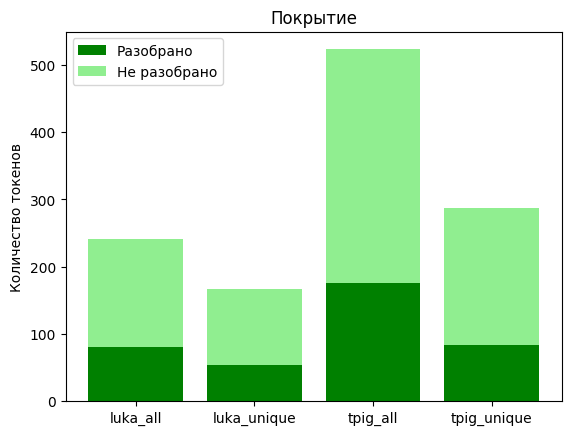

In [ ]:
import matplotlib.pyplot as plt

bars = ['luka_all', 'luka_unique', 'tpig_all', 'tpig_unique']

all = [241, 167, 523, 287]
analysed = [241-160, 167-113, 523-347, 287-203]

plt.bar(bars, analysed, color='green', label='Разобрано')
plt.bar(bars, [в - р for в, р in zip(all, analysed)],
        bottom=analysed, color='lightgreen', label='Не разобрано')

plt.ylabel('Количество токенов')
plt.title('Покрытие')
plt.legend()
plt.show()

In [103]:
df3 = df3.drop_duplicates(subset=['cyr'], keep='first')


In [104]:
df3

,cyr,lat,gloss,my_gloss
0,хlуьлматлу,Hylmatlu,уважаемый,хlуьлматлу
1,дусттар,dusT-ar,друг-Pl,дустт pl
2,гьеме,he-me,ha-DemM,*гьеме
3,китабис,kitab.i-s,книга-Dat,китаб erg dat
4,агъая,aR.a-ja,говорить.Ipf-Prs,*агъая
...,...,...,...,...
232,хабарин,Xabar.i-n,весть-Gen,NaN
236,аттархьуна,aTarx.u-na,In-Elat:попадать.Pf-Conv,NaN
237,агъулар,aRul-ar,агульский-Pl,NaN
238,шад,]ad,радостный,NaN
